In [2]:
from pathlib import Path
import json
import os
import numpy as np
from tabulate import tabulate

ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Metrics_multilabel')

PATH_ASL  = ROOT / 'global_report_strategy_None_ASL.json'
PATH_NONE = ROOT / 'global_report_strategy_None_None.json'
PATH_PW   = ROOT / 'global_report_strategy_None_PW.json'
PATH_WS   = ROOT / 'global_report_strategy_WS_None.json'

def load_json(path, name):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error leyendo el archivo {name}: {e}")
        return None

# Intentar cargar todos los datos
data_ASL = load_json(PATH_ASL, "None_ASL")
data_None = load_json(PATH_NONE, "None_None")
data_PW = load_json(PATH_PW, "None_PW")
data_WS = load_json(PATH_WS, "WS_None")

# Validar que todos los archivos se hayan leído correctamente
if not all([data_ASL, data_None, data_PW, data_WS]):
    print("\nEl script se detuvo porque falta configurar o cargar uno o más archivos JSON.")
    exit()

# Agrupación de los diccionarios cargados
methods = {
    "None_ASL": data_ASL,
    "None_None": data_None,
    "None_PW": data_PW,
    "WS_None": data_WS
}

# Mapeo de métricas: (Estrategia en el JSON, Nombre de la clave interna)
metrics_mapping = {
    "F1-Score (Default 0.5)": ("default_0.5", "f1_score"),
    "F1-Score (Optimized)": ("optimized", "f1_score"),
    "PR-AUC": ("independent", "PR-AUC"),
    "ROC-AUC": ("independent", "ROC-AUC"),
    "Umbrales Optimizados (Best Threshold)": ("optimized", "best_threshold")
}

classes = list(data_ASL.keys())

def calculate_macro(method_data, strategy, metric_name):
    """Calcula el promedio macro y propaga correctamente la desviación estándar."""
    means = []
    stds = []
    for c in classes:
        means.append(method_data[c][strategy][metric_name]["mean"])
        stds.append(method_data[c][strategy][metric_name]["std"])
    
    macro_mean = np.mean(means)
    # Propagación de errores para una media: sqrt(sum(std^2)) / N
    macro_std = np.sqrt(np.sum(np.square(stds))) / len(classes)
    return macro_mean, macro_std

# Bucle principal para generar las tres tablas comparativas
for label, (strat, dict_key) in metrics_mapping.items():
    print(f"\n" + "="*65)
    print(f" COMPARATIVA PARA LA MÉTRICA: {label}")
    print("="*65)
    
    table_data = []
    
    # Filas por cada clase/lesión
    for c in classes:
        row = [c]
        for m_name, m_data in methods.items():
            val_mean = m_data[c][strat][dict_key]["mean"]
            val_std = m_data[c][strat][dict_key]["std"]
            row.append(f"{val_mean:.4f} ± {val_std:.4f}")
        table_data.append(row)
    
    # Línea de separación visual para el promedio general
    table_data.append(["-"*25] + ["-"*18]*len(methods))
    
    # Fila final con el cálculo Macro
    macro_row = ["MACRO AVERAGE"]
    for m_name, m_data in methods.items():
        m_mean, m_std = calculate_macro(m_data, strat, dict_key)
        macro_row.append(f"{m_mean:.4f} ± {m_std:.4f}")
    table_data.append(macro_row)
    
    # Cabeceras de la tabla
    headers = ["Clase / Lesión"] + list(methods.keys())
    print(tabulate(table_data, headers=headers, tablefmt="grid"))


 COMPARATIVA PARA LA MÉTRICA: F1-Score (Default 0.5)
+---------------------------+--------------------+--------------------+--------------------+--------------------+
| Clase / Lesión            | None_ASL           | None_None          | None_PW            | WS_None            |
+===========================+====================+====================+====================+====================+
| normal                    | 0.7069 ± 0.0750    | 0.7923 ± 0.0417    | 0.7879 ± 0.0450    | 0.7572 ± 0.0351    |
+---------------------------+--------------------+--------------------+--------------------+--------------------+
| lowgrade_dysplasia        | 0.8102 ± 0.0761    | 0.8744 ± 0.0352    | 0.8699 ± 0.0349    | 0.8414 ± 0.0349    |
+---------------------------+--------------------+--------------------+--------------------+--------------------+
| inflammation              | 0.1635 ± 0.0612    | 0.0450 ± 0.0380    | 0.1578 ± 0.0570    | 0.1083 ± 0.0481    |
+---------------------------+-----

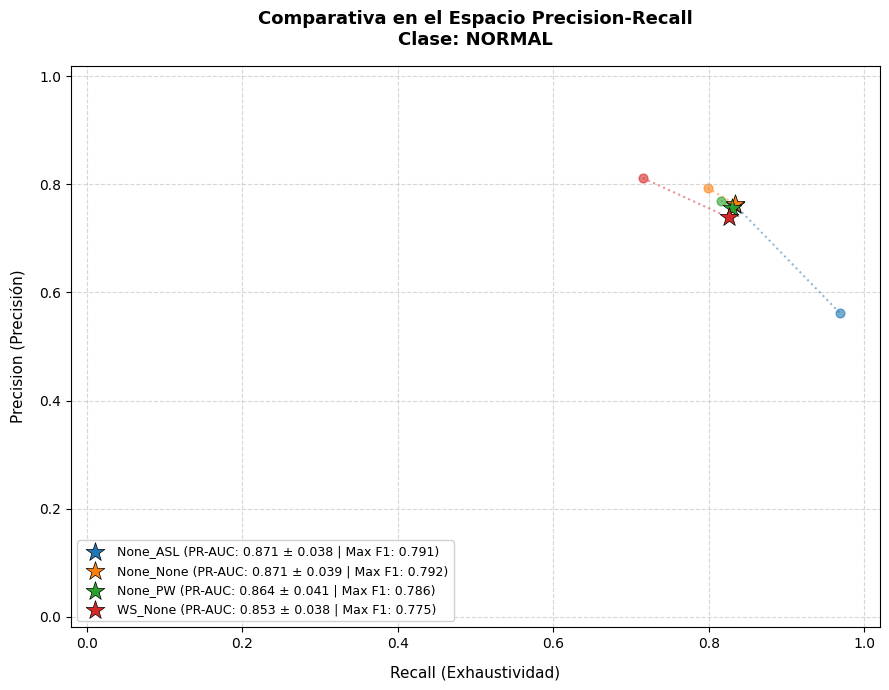

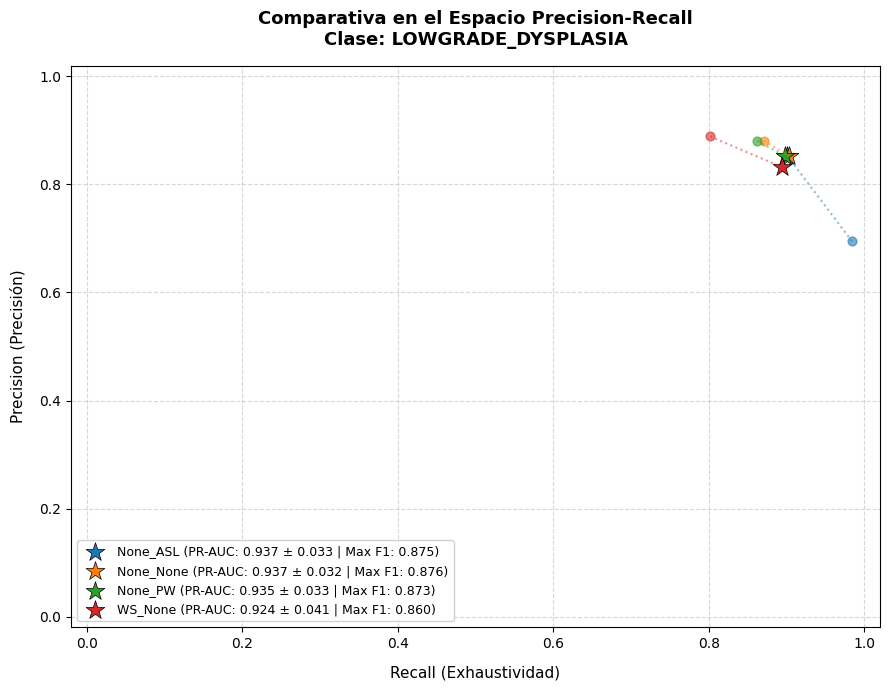

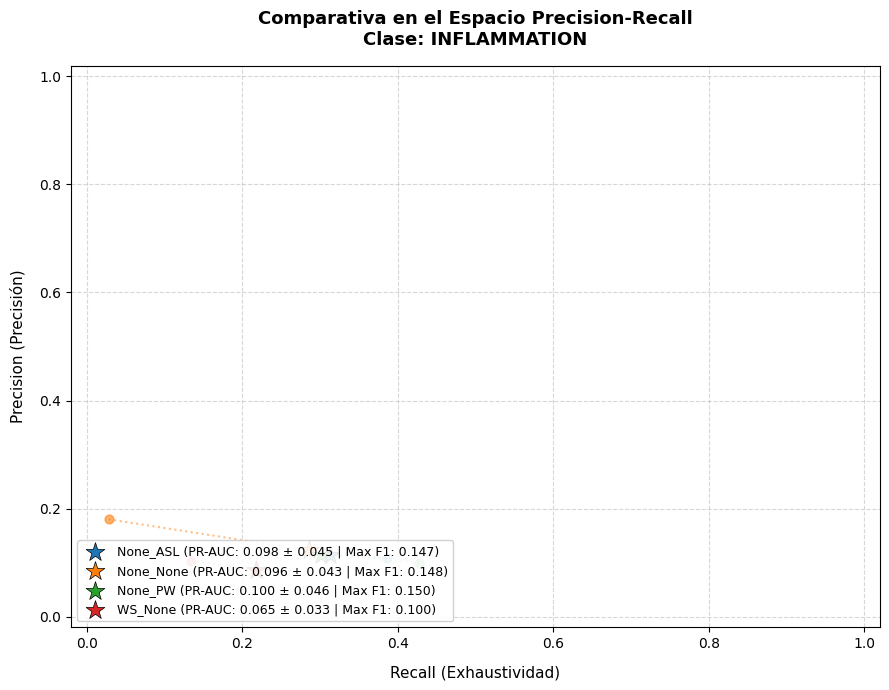

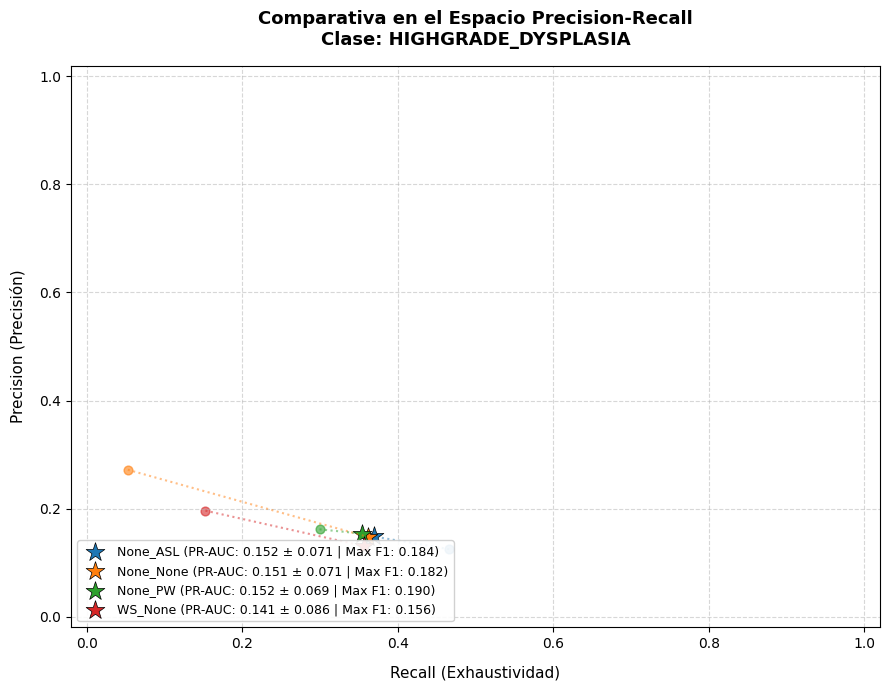

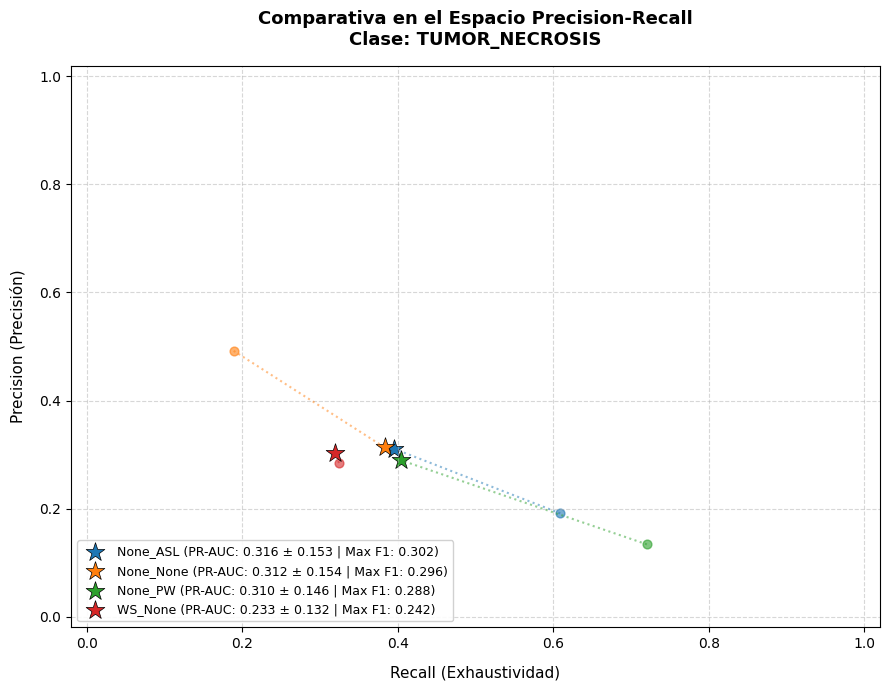

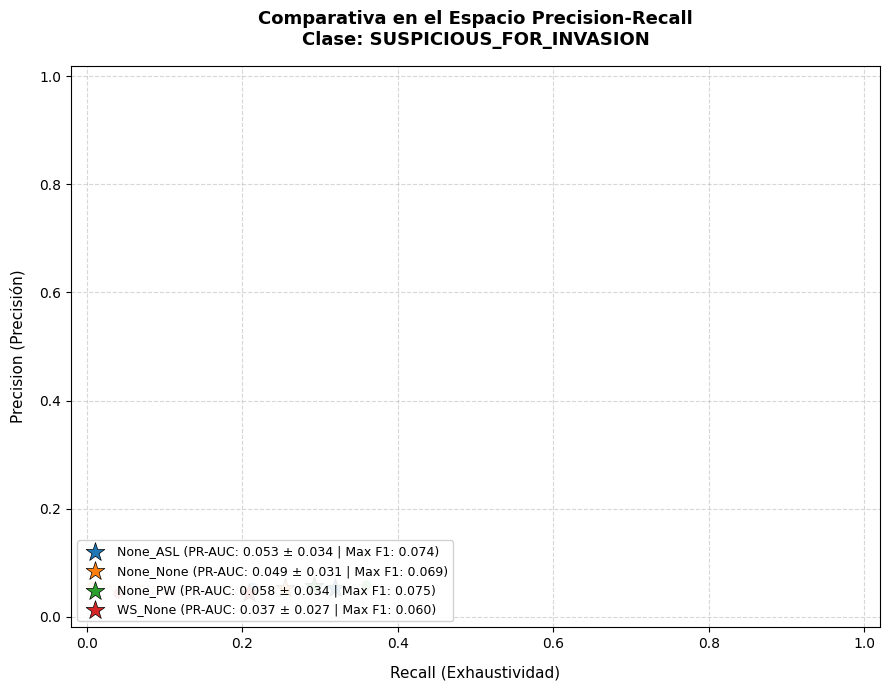

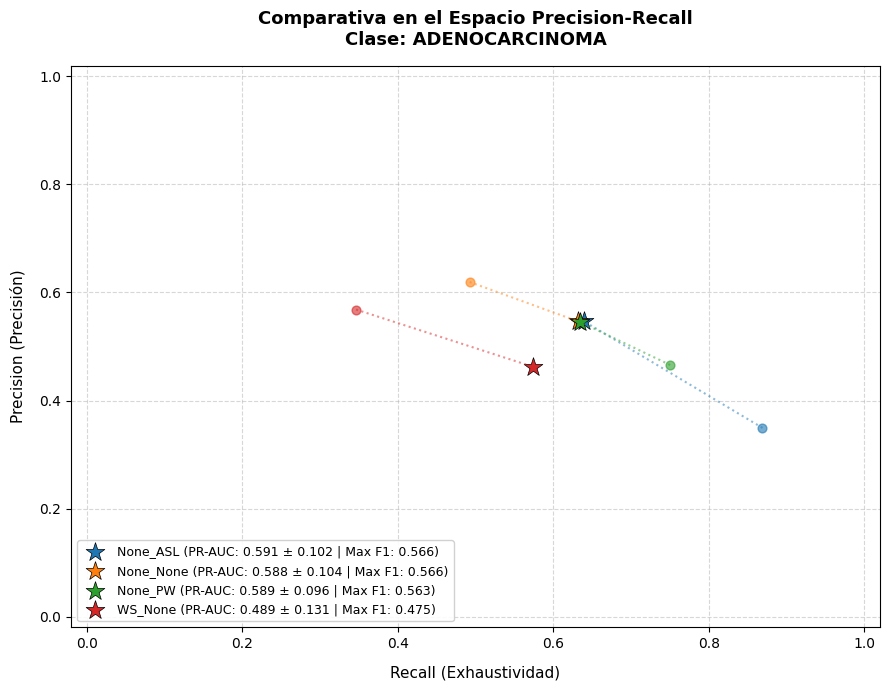

In [3]:
import matplotlib.pyplot as plt
classes = list(data_ASL.keys())

# Iterar por cada clase para generar un gráfico individual
for c in classes:
    # Crear una nueva figura para la clase actual
    plt.figure(figsize=(9, 7))
    
    for m_name, m_data in methods.items():
        # 1. Obtener el valor de PR-AUC (área bajo la curva) para la leyenda
        pr_auc_mean = m_data[c]["independent"]["PR-AUC"]["mean"]
        pr_auc_std = m_data[c]["independent"]["PR-AUC"]["std"]
        
        # 2. Obtener las coordenadas del punto por defecto (Umbral 0.5)
        p_def = m_data[c]["default_0.5"]["precision"]["mean"]
        r_def = m_data[c]["default_0.5"]["recall"]["mean"]
        
        # 3. Obtener las coordenadas del punto optimizado (Máximo F1-Score)
        p_opt = m_data[c]["optimized"]["precision"]["mean"]
        r_opt = m_data[c]["optimized"]["recall"]["mean"]
        f1_opt = m_data[c]["optimized"]["f1_score"]["mean"]
        f1_std = m_data[c]["optimized"]["f1_score"]["std"]
        
        # Dibujar una línea punteada que une el punto por defecto con el optimizado
        line, = plt.plot([r_def, r_opt], [p_def, p_opt], linestyle=':', alpha=0.5, linewidth=1.5)
        color = line.get_color()
        
        # Graficar el punto inicial (Umbral 0.5) como un círculo pequeño
        plt.scatter(r_def, p_def, color=color, marker='o', s=40, alpha=0.6)
        
        # Graficar el punto de F1 Máximo como una ESTRELLA grande
        label_text = f"{m_name} (PR-AUC: {pr_auc_mean:.3f} ± {pr_auc_std:.3f} | Max F1: {f1_opt:.3f})"
        plt.scatter(r_opt, p_opt, color=color, marker='*', s=200, edgecolors='black', linewidths=0.5, label=label_text)
        
    # Configuración estricta del espacio de Precision-Recall
    plt.title(f"Comparativa en el Espacio Precision-Recall\nClase: {c.upper()}", fontsize=13, fontweight='bold', pad=15)
    plt.xlabel("Recall (Exhaustividad)", fontsize=11, labelpad=10)
    plt.ylabel("Precision (Precisión)", fontsize=11, labelpad=10)
    
    # Límites fijos de 0 a 1 para evaluar correctamente el espacio real
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc="lower left", fontsize=9, framealpha=0.9, shadow=False)
    plt.tight_layout()
    
    # Opcional: Descomenta la siguiente línea si quieres guardar los gráficos directamente en tu carpeta
    # plt.savefig(ROOT / f"Grafico_PR_{c}.png", dpi=300)
    
    # Mostrar el gráfico por pantalla
    plt.show()

In [ ]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# ==========================================
# CONFIGURACIÓN DEL EXPERIMENTO
# ==========================================
CLASSES = [
    'normal',
    'lowgrade_dysplasia',
    'inflammation',
    'highgrade_dysplasia',
    'tumor_necrosis',
    'suspicious_for_invasion',
    'adenocarcinoma',
]
ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Model_output')


SEEDS = [22, 32, 42, 52, 62]  
FOLDS = [1, 2, 3, 4, 5]
METHODS = ['None_None', 'None_PW', 'None_ASL', 'WS_None']

# CORRECCIÓN: Se cambia 'WS_none' a 'WS_None' para que coincida exactamente con la lista METHODS
COLORS = {
    'None_None': '#1f77b4', 
    'None_PW': '#2ca02c', 
    'None_ASL': '#d62728', 
    'WS_None': '#bcbd22'  # Un tono oliva/amarillo muy elegante para gráficos científicos
}

# CORRECCIÓN: Se añade la traducción de 'WS_None' para que no falle al generar la leyenda
LABELS = {
    'None_None': 'Baseline (BCE)', 
    'None_PW': 'Pos Weights (PW)', 
    'None_ASL': 'Asymmetric Loss (ASL)',
    'WS_None': 'Weighted Sampler (WS)'
}

threshold_sweep = np.linspace(0.01, 0.99, 100)

# Estructura para almacenar las curvas de test de cada combinación
data_storage = {m: {c: {'test_curves': [], 'opt_t_val': [], 'test_f1_opt': []} for c in CLASSES + ['macro_average']} for m in METHODS}

# ==========================================
# EXTRACCIÓN Y PROCESAMIENTO DE DATOS
# ==========================================
print("Procesando archivos CSV y calculando espacios de fases...")

for seed in SEEDS:
    for fold in FOLDS:
        for method in METHODS:
            val_path = ROOT / f"predictions_seed_{seed}_fold{fold}_{method}_val.csv"
            test_path = ROOT / f"predictions_seed_{seed}_fold{fold}_{method}_test.csv"
            
            # Se usa .exists() propio de pathlib que es más robusto
            if not (val_path.exists() and test_path.exists()):
                continue
                
            df_val = pd.read_csv(val_path)
            df_test = pd.read_csv(test_path)
            
            run_macro_test_curve = np.zeros(len(threshold_sweep))
            run_macro_val_curve = np.zeros(len(threshold_sweep))
            
            # --- PASO 1: Calcular curvas por cada clase individual ---
            for cls in CLASSES:
                y_true_val = df_val[f"{cls}_true"].values
                y_prob_val = df_val[f"{cls}_prob"].values
                y_true_test = df_test[f"{cls}_true"].values
                y_prob_test = df_test[f"{cls}_prob"].values
                
                cls_val_curve = []
                cls_test_curve = []
                for t in threshold_sweep:
                    # Validación
                    pred_val = (y_prob_val >= t).astype(int)
                    cls_val_curve.append(f1_score(y_true_val, pred_val, zero_division=0))
                    # Test
                    pred_test = (y_prob_test >= t).astype(int)
                    cls_test_curve.append(f1_score(y_true_test, pred_test, zero_division=0))
                
                cls_test_curve = np.array(cls_test_curve)
                cls_val_curve = np.array(cls_val_curve)
                
                run_macro_test_curve += cls_test_curve / len(CLASSES)
                run_macro_val_curve += cls_val_curve / len(CLASSES)
                
                data_storage[method][cls]['test_curves'].append(cls_test_curve)
                
                best_t_idx = np.argmax(cls_val_curve)
                best_t = threshold_sweep[best_t_idx]
                data_storage[method][cls]['opt_t_val'].append(best_t)
                data_storage[method][cls]['test_f1_opt'].append(cls_test_curve[best_t_idx])
            
            # --- PASO 2: Guardar la métrica combinada Macro de este run ---
            data_storage[method]['macro_average']['test_curves'].append(run_macro_test_curve)
            best_macro_t_idx = np.argmax(run_macro_val_curve)
            data_storage[method]['macro_average']['opt_t_val'].append(threshold_sweep[best_macro_t_idx])
            data_storage[method]['macro_average']['test_f1_opt'].append(run_macro_test_curve[best_macro_t_idx])

# ==========================================
# GENERACIÓN DE IMÁGENES INDIVIDUALES
# ==========================================
print("\nGenerando gráficos individuales...")
plot_targets = CLASSES + ['macro_average']

for target in plot_targets:
    # Creamos un lienzo independiente para cada clase o métrica macro (evitando .figure())
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for method in METHODS:
        curves = np.array(data_storage[method][target]['test_curves'])
        if len(curves) == 0: 
            continue
        
        # Estadísticos de la curva continua (F1 vs Umbral)
        mean_curve = np.mean(curves, axis=0)
        std_curve = np.std(curves, axis=0)
        
        # Estadísticos del punto óptimo validado
        mean_t = np.mean(data_storage[method][target]['opt_t_val'])
        mean_f1 = np.mean(data_storage[method][target]['test_f1_opt'])
        
        # 1. Línea continua de la media
        # Para que el gráfico sea auto-explicativo sin las barras de error, metemos el tau óptimo teórico en la leyenda
        label_text = f"{LABELS[method]} ($\tau^* = {mean_t:.2f}$)"
        ax.plot(threshold_sweep, mean_curve, color=COLORS[method], linestyle='-', linewidth=2, label=label_text)
        
        # 2. Banda de incertidumbre estadística (±1 Desviación Estándar)
        ax.fill_between(threshold_sweep, mean_curve - std_curve, mean_curve + std_curve, 
                        color=COLORS[method], alpha=0.12)
        
        # 3. Marcador del óptimo LIMPIO (Se elimina ax.errorbar y se usa un punto sólido destacado)
        ax.plot(mean_t, mean_f1, marker='o', color=COLORS[method], markersize=8, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
        
    # Formato estético riguroso (Estilo memoria LaTeX / TFG)
    title_name = target.upper().replace('_', ' ')
    if target != 'macro_average':
        ax.set_title(f"Espacio de Calibración: Clase {title_name}", fontsize=13, fontweight='bold', pad=15)
    else:
        ax.set_title("RENDIMIENTO GLOBAL DEL SISTEMA (MACRO OVERALL)", fontsize=13, fontweight='bold', pad=15)
        
    ax.set_xlabel("Umbral de Clasificación ($\tau$)", fontsize=11)
    ax.set_ylabel("F1-Score (Test)", fontsize=11)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc="lower left", fontsize=10, frameon=True, shadow=True)
    
    plt.tight_layout()
    
    # Guardado individualizado de cada archivo
    filename = f"calibracion_{target}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close(fig)  # Cierra la figura actual para liberar la memoria RAM y evitar solapamientos
    print(f" -> Imagen exportada con éxito: {filename}")

print("\n¡Procesamiento completo! Revisa tu directorio de ejecución.")

Procesando archivos CSV y calculando espacios de fases...

Generando gráficos individuales...
 -> Imagen exportada con éxito: calibracion_normal.png
 -> Imagen exportada con éxito: calibracion_lowgrade_dysplasia.png
 -> Imagen exportada con éxito: calibracion_inflammation.png
 -> Imagen exportada con éxito: calibracion_highgrade_dysplasia.png
 -> Imagen exportada con éxito: calibracion_tumor_necrosis.png
 -> Imagen exportada con éxito: calibracion_suspicious_for_invasion.png
 -> Imagen exportada con éxito: calibracion_adenocarcinoma.png
 -> Imagen exportada con éxito: calibracion_macro_average.png

¡Procesamiento completo! Revisa tu directorio de ejecución.


In [9]:
import pandas as pd
import torch
from pathlib import Path 

ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')

lista_resultados = []

SEEDS = [22, 32, 42, 52, 62]
NUM_FOLDS = 5

for fold in range(1, NUM_FOLDS + 1):
    for seed in SEEDS:
        csv_path = ROOT  / 'Model_output' / f'predictions_seed_{seed}_fold{fold}_None_ASL_val.csv'
        CKPT_DIR = ROOT / 'Model_output' / f'best_model_seed_{seed}_fold_{fold}_strategy_None_ASL.pth'
        checkpoint = torch.load(CKPT_DIR, map_location='cpu')
        umbral = checkpoint['thresholds']
        
        try:
            # Leer el CSV
            df = pd.read_csv(csv_path)
            
            # Identificar automáticamente las columnas dinámicas
            true_cols = [c for c in df.columns if c.endswith('_true')]
            prob_cols = [c for c in df.columns if c.endswith('_prob')]
            
            # Validar que el CSV tenga la estructura correcta
            if not true_cols or not prob_cols:
                print(f"Saltando '{csv_path}': No contiene el formato '_true' y '_prob'.")
                continue
            
            etiquetas_reales_por_fila = df[true_cols].sum(axis=1)
            etiquetas_predichas_por_fila = (df[prob_cols] >= umbral).sum(axis=1)
            
            # --- CÁLCULOS POR ARCHIVO ---
            eran_multilabel = etiquetas_reales_por_fila > 1
            predijo_multilabel = etiquetas_predichas_por_fila > 1
            eran_single_label = etiquetas_reales_por_fila == 1
            
            # M1: Reales multilabel
            total_eran_multilabel = eran_multilabel.sum()
            
            # M2: Bien predichos como multilabel (eran multilabel y el modelo vio > 1 etiqueta)
            multilabel_bien_identificado = (eran_multilabel & predijo_multilabel).sum()
            
            # M3: Mal predichos como multilabel (eran 1 sola etiqueta y el modelo vio > 1)
            falsos_multilabel = (eran_single_label & predijo_multilabel).sum()
            
            # Total de predicciones multilabel en este archivo (para el % final)
            total_predicho_multilabel = predijo_multilabel.sum()
            
            lista_resultados.append({
                'Archivo': csv_path,
                'Total_Casos': len(df),
                'Real_Multilabel': total_eran_multilabel,
                'Bien_Predicho_Multilabel': multilabel_bien_identificado,
                'Mal_Predicho_Multilabel': falsos_multilabel,
                'Total_Predicho_Multilabel': total_predicho_multilabel
            })
            
        except Exception as e:
            print(f"❌ Error al procesar '{csv_path}': {e}")
        
# Convertir todos los resultados a un DataFrame final
df_informe = pd.DataFrame(lista_resultados)

if df_informe is not None and not df_informe.empty:
    print("\n📊 REPORTE DE COMPORTAMIENTO MULTILABEL:")
    print(df_informe.to_string(index=False))
    
    # Opcional: Guardar este reporte consolidado en un nuevo archivo CSV
    df_informe.to_csv(ROOT / "acierto_multilabel_ASL.csv", index=False)
    print("\n💾 ¡Reporte guardado como 'reporte_consolidado_multilabel.csv'!")
    
# =====================================================================
# CÁLCULO DE TOTALES GLOBALES (SUMATORIAS Y PORCENTAJES)
# =====================================================================
grand_total_casos = df_informe['Total_Casos'].sum()
grand_total_reales = df_informe['Real_Multilabel'].sum()
grand_total_bien_predichos = df_informe['Bien_Predicho_Multilabel'].sum()
grand_total_mal_predichos = df_informe['Mal_Predicho_Multilabel'].sum()
grand_total_predichos = df_informe['Total_Predicho_Multilabel'].sum()

# Calcular porcentajes globales sobre el total de casos
porcentaje_real_global = (grand_total_reales / grand_total_casos) * 100
porcentaje_predicho_global = (grand_total_predichos / grand_total_casos) * 100

print("\n" + "="*60)
print("📈 RESUMEN CONSOLIDADO DE LA CARPETA")
print("="*60)
print(f"• Total absoluto de casos analizados:   {grand_total_casos:,}")
print(f"• Total de casos REALES multilabel:     {grand_total_reales:,}")
print(f"• Total BIEN predichos como multilabel: {grand_total_bien_predichos:,}")
print(f"• Total MAL predichos (Falsos M-Label): {grand_total_mal_predichos:,}")
print("-"*60)
print(f"• PORCENTAJE REAL multilabel en el dataset:   {porcentaje_real_global:.2f}%")
print(f"• PORCENTAJE PREDICHO multilabel por modelo:  {porcentaje_predicho_global:.2f}%")
print("="*60)


📊 REPORTE DE COMPORTAMIENTO MULTILABEL:
                                                                                                         Archivo  Total_Casos  Real_Multilabel  Bien_Predicho_Multilabel  Mal_Predicho_Multilabel  Total_Predicho_Multilabel
C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Model_output\predictions_seed_22_fold1_None_ASL_val.csv        19089              208                        95                     4000                       4095
C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Model_output\predictions_seed_32_fold1_None_ASL_val.csv        21482              117                        77                     4696                       4773
C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Model_output\predictions_seed_42_fold1_None_ASL_val.csv        23757              200                        40                     1624                       1664
C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Model_output\predi

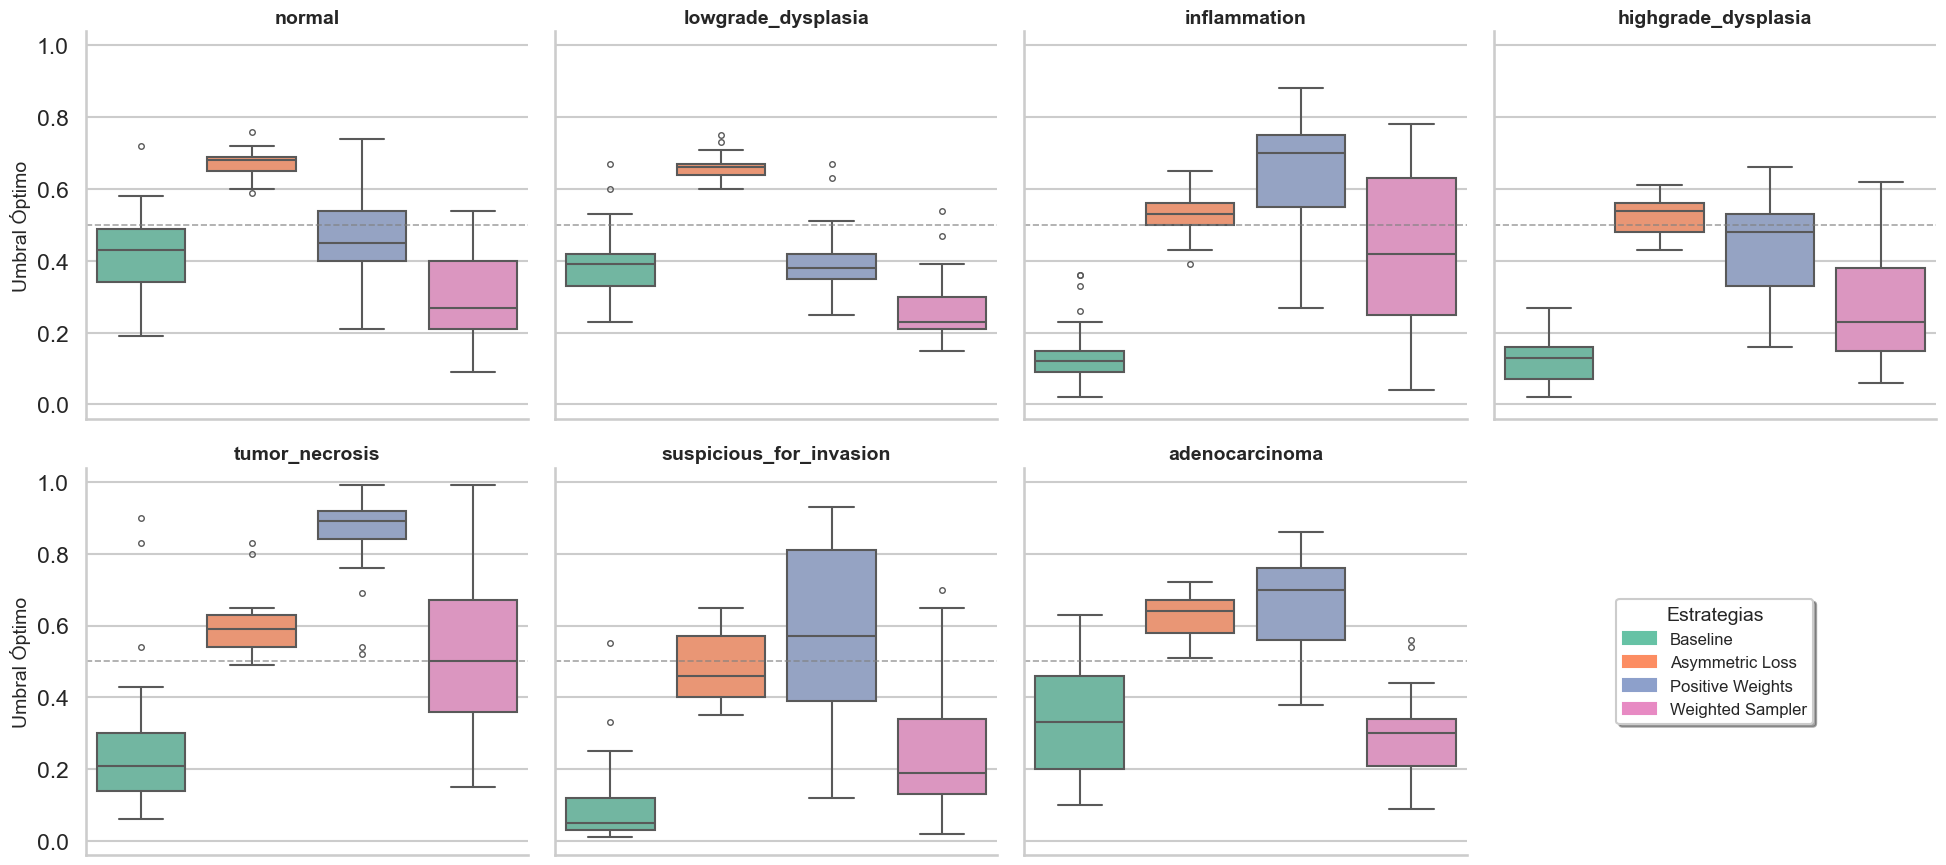

In [12]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.patches as mpatches

# --- CONFIGURACIÓN ---
# Reemplaza esto con la ruta de la carpeta donde están tus archivos JSON
ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')

LEYENDA_PERSONALIZADA = {
    "None_None": "Baseline",
    "None_ASL" : "Asymmetric Loss",
    "None_PW"  : "Positive Weights",
    "WS_None"  : "Weighted Sampler"
}

SEEDS = [22, 32, 42, 52, 62]
NUM_FOLDS = 5
METODOS = ["None_None", "None_ASL", "None_PW", "WS_None"]
FOLDS = list(range(1, NUM_FOLDS + 1)) # [1, 2, 3, 4, 5]

registros = []

for seed in SEEDS:
    for fold in FOLDS:
        for metodo in METODOS:
            nombre_archivo = f"report_seed_{seed}_fold_{fold}_strategy_{metodo}.json"
            ruta_completa = os.path.join(ROOT / 'Metrics_multilabel', nombre_archivo)
            
            if os.path.exists(ruta_completa):
                with open(ruta_completa, 'r') as f:
                    data = json.load(f)
                
                for clase, metricas in data.items():
                    if "optimized" in metricas and "best_threshold" in metricas["optimized"]:
                        threshold = metricas["optimized"]["best_threshold"]
                        registros.append({
                            "Method": metodo, 
                            "Class": clase,
                            "Best_Threshold": threshold
                        })

df = pd.DataFrame(registros)

# --- 2. PROCESAMIENTO DE TEXTOS Y ORDEN ---
if not df.empty:
    df["Method"] = df["Method"].map(LEYENDA_PERSONALIZADA)
    orden_nombres_nuevos = [LEYENDA_PERSONALIZADA[m] for m in METODOS]

    # --- 3. GENERACIÓN DEL GRÁFICO ---
    sns.set_theme(style="whitegrid", context="talk")
    
    g = sns.catplot(
        data=df,
        x="Method",
        y="Best_Threshold",
        hue="Method",
        hue_order=orden_nombres_nuevos, # Mantiene fijos los colores (Verde, Naranja, Azul, Rosa)
        col="Class",
        col_wrap=4,                     # Cuadrícula de 2 filas x 4 columnas
        kind="box",
        palette="Set2", 
        height=4.5,
        aspect=1.1,
        sharey=True,
        linewidth=1.5,
        fliersize=4,
        legend=False                    # Evitamos que Seaborn pinte su leyenda rota
    )
    
    # Configuración de líneas de referencia y limpieza de ejes
    for ax in g.axes.flat:
        ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7, linewidth=1.2)
        ax.set_xticklabels([])          # Mantiene el look limpio que ya lograste
        ax.set_xlabel("")
        
    g.set_titles("{col_name}", weight='bold', size=14)
    g.set_axis_labels("", "Umbral Óptimo", size=14)
    
    # --- 4. SOLUCIÓN: CONSTRUCCIÓN DE LEYENDA MANUAL EN EL HUECO 8 ---
    ax_vacio = g.fig.add_subplot(2, 4, 8)
    ax_vacio.axis('off') # Ocultamos los ejes del octavo cuadrante
    
    # Extraemos la paleta exacta de colores de Seaborn para clonarla
    colores_paleta = sns.color_palette("Set2", len(orden_nombres_nuevos))
    
    # Creamos los cuadraditos manualmente asociando color con tu texto transformado
    handles_manuales = [
        mpatches.Patch(color=colores_paleta[i], label=nombre)
        for i, nombre in enumerate(orden_nombres_nuevos)
    ]
    
    # Forzamos el renderizado de la leyenda con los parches reales
    ax_vacio.legend(
        handles=handles_manuales, 
        title="Estrategias", 
        loc="center",         # Centrado perfecto en el espacio vacío
        frameon=True,
        shadow=True,
        fontsize=12,
        title_fontsize=14
    )
    
    plt.tight_layout()
    plt.savefig(ROOT / 'plots_interesantes' / "distribucion_thresholds.png", dpi=300, bbox_inches='tight')
    plt.show()

🚀 Iniciando la acumulación de predicciones...
✅ Conteo acumulado finalizado con éxito.


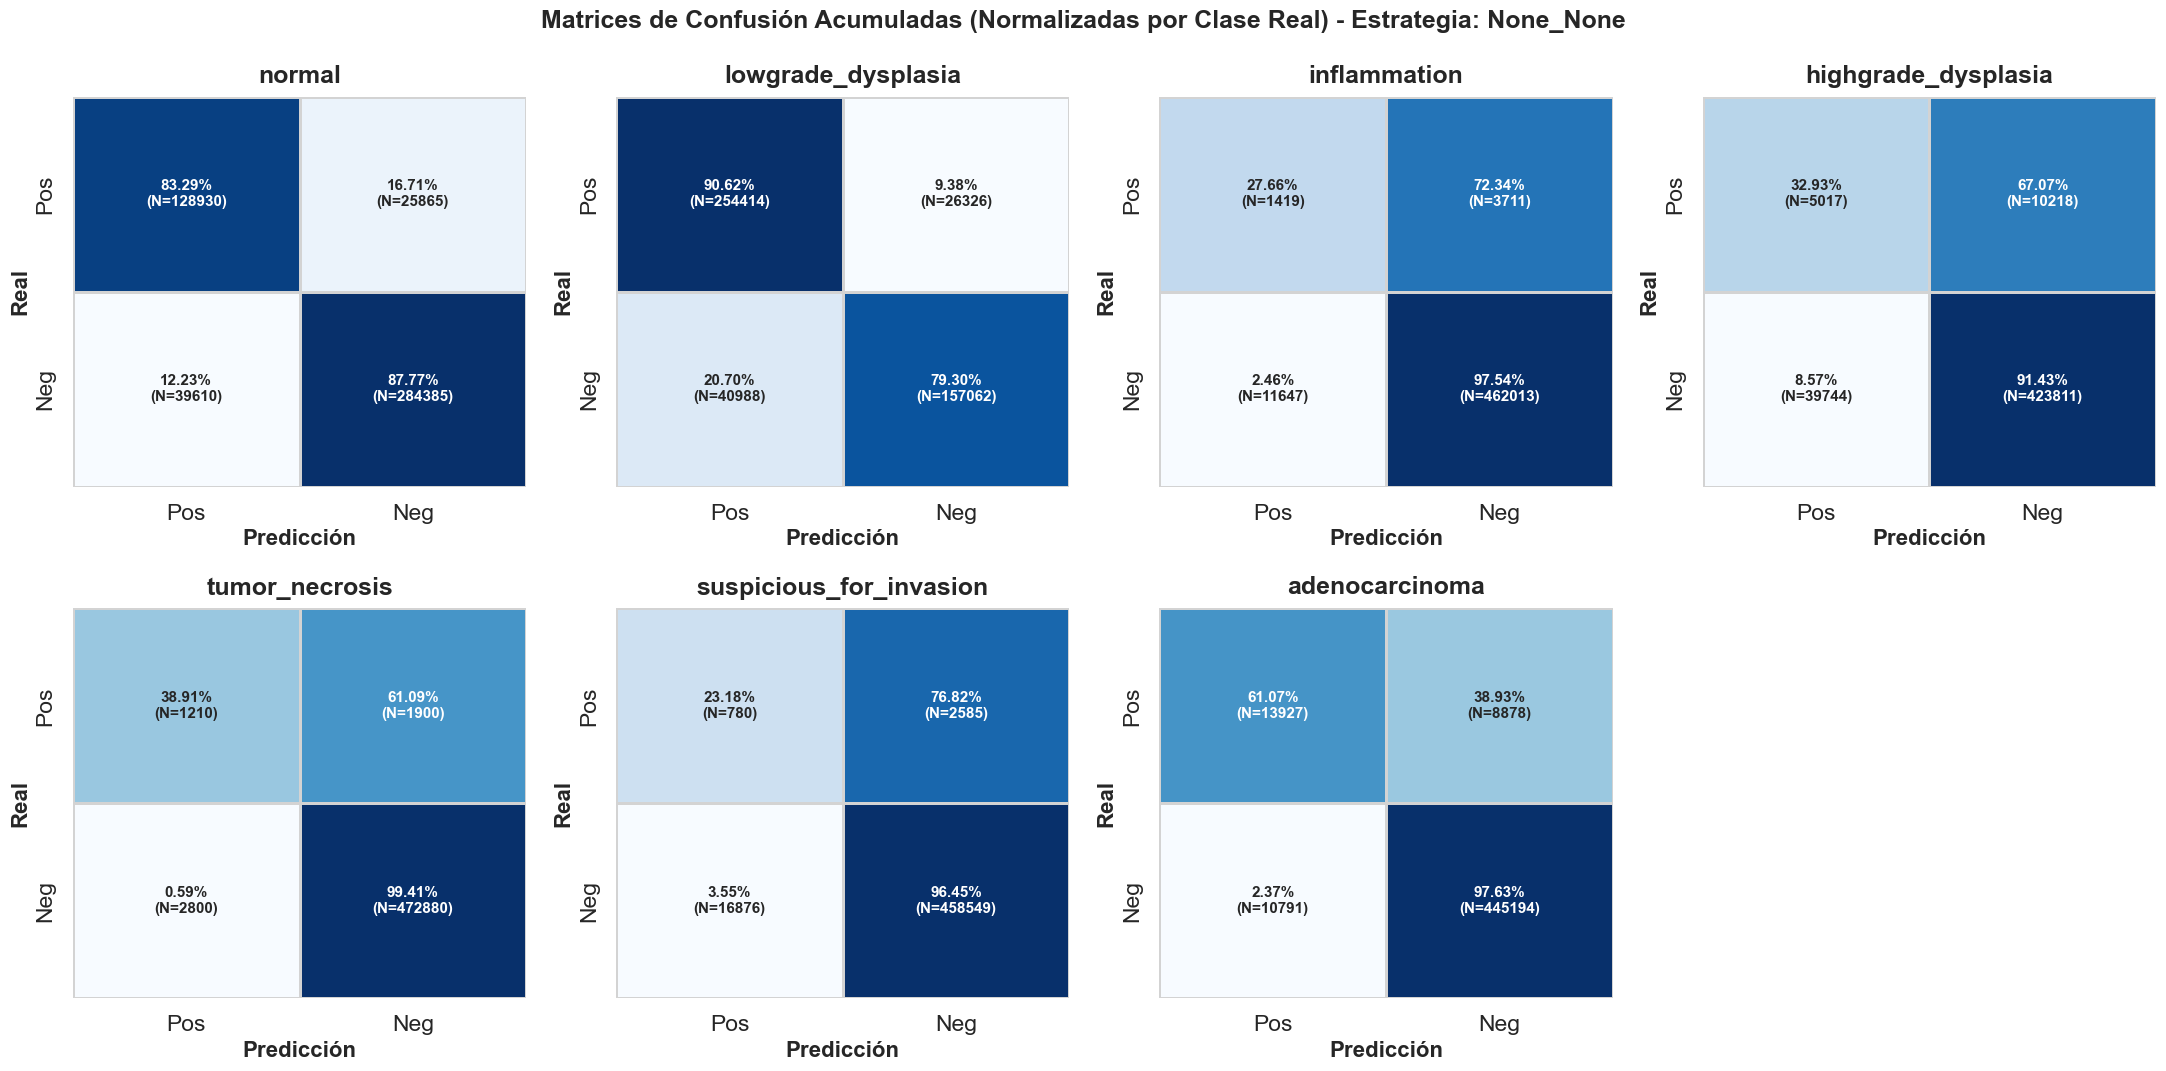

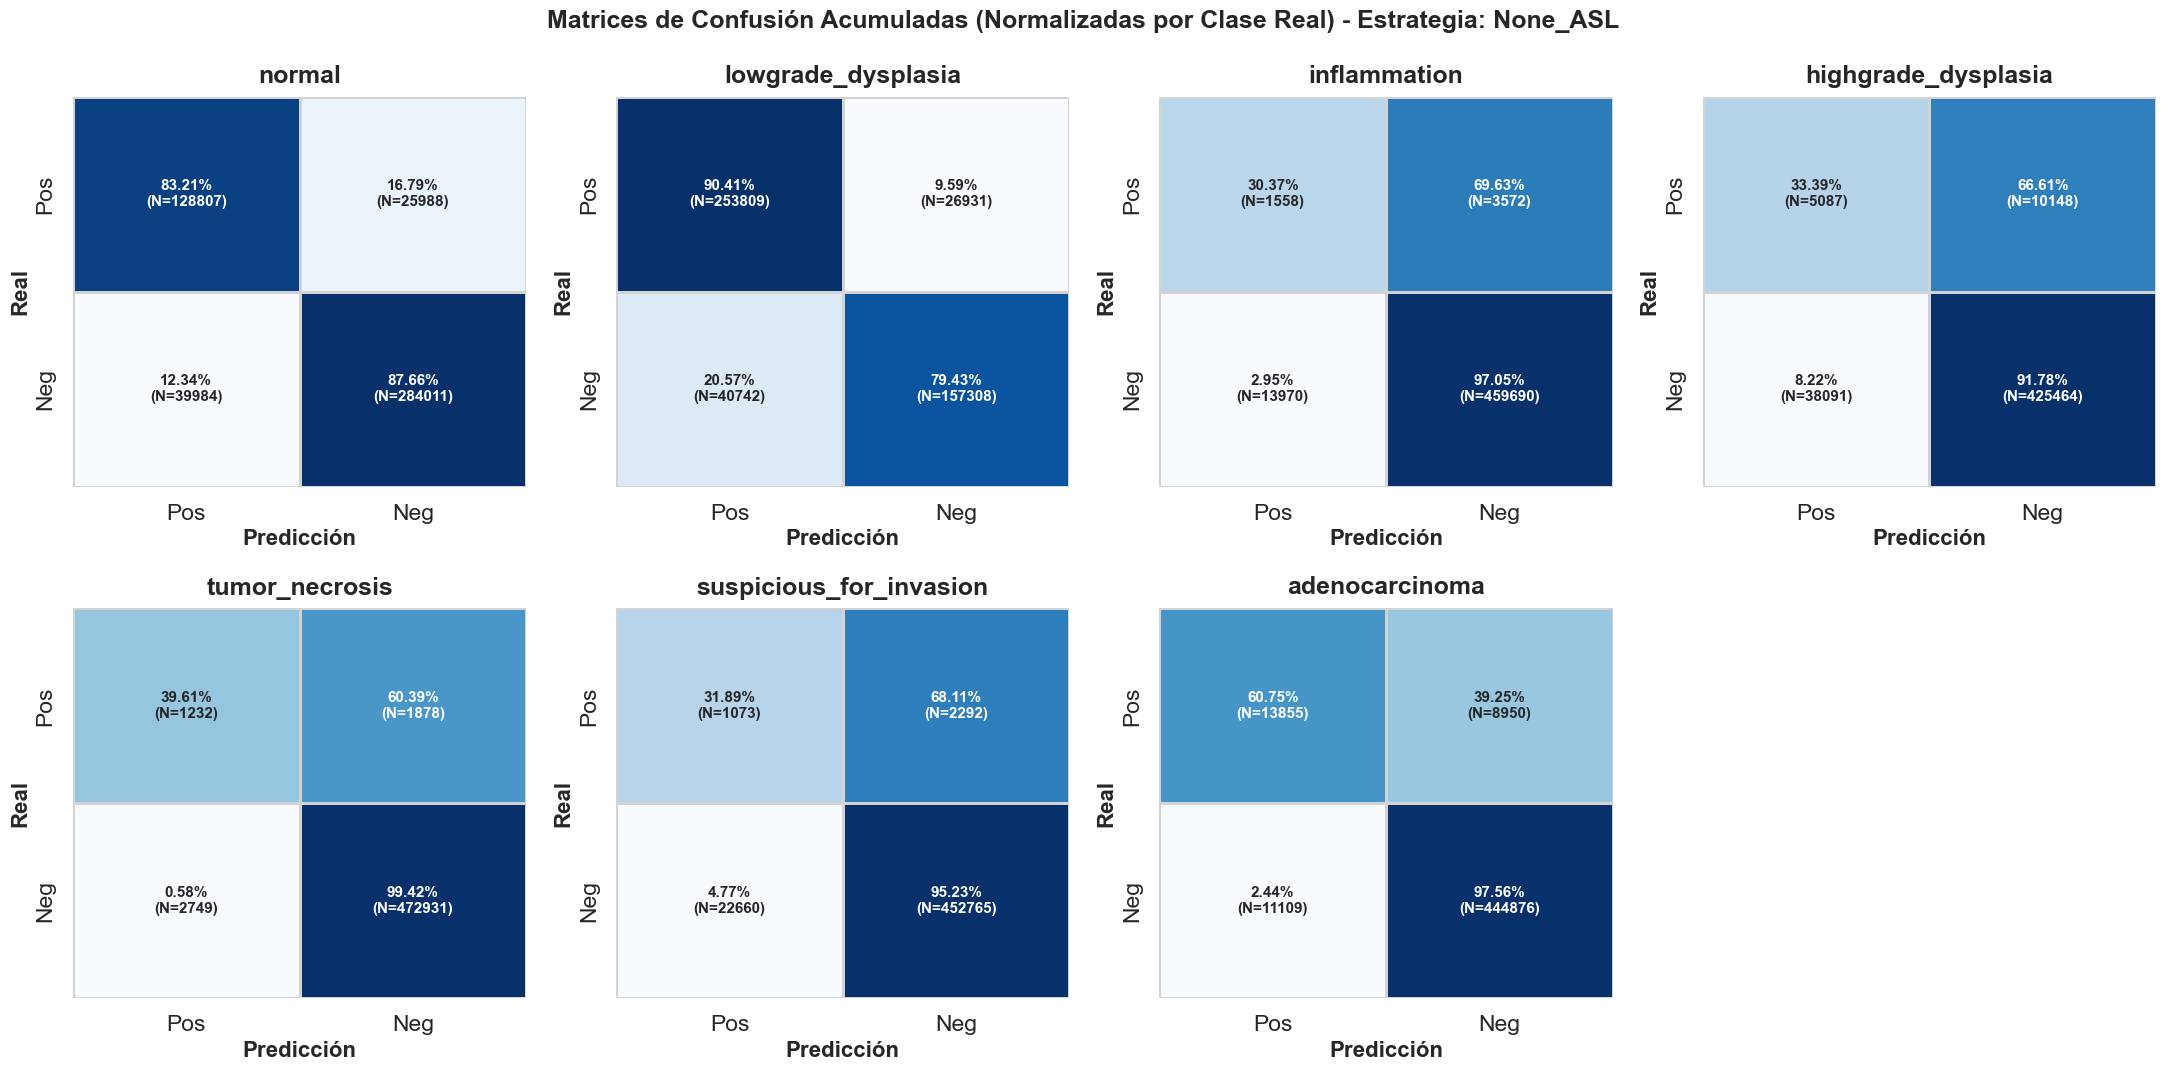

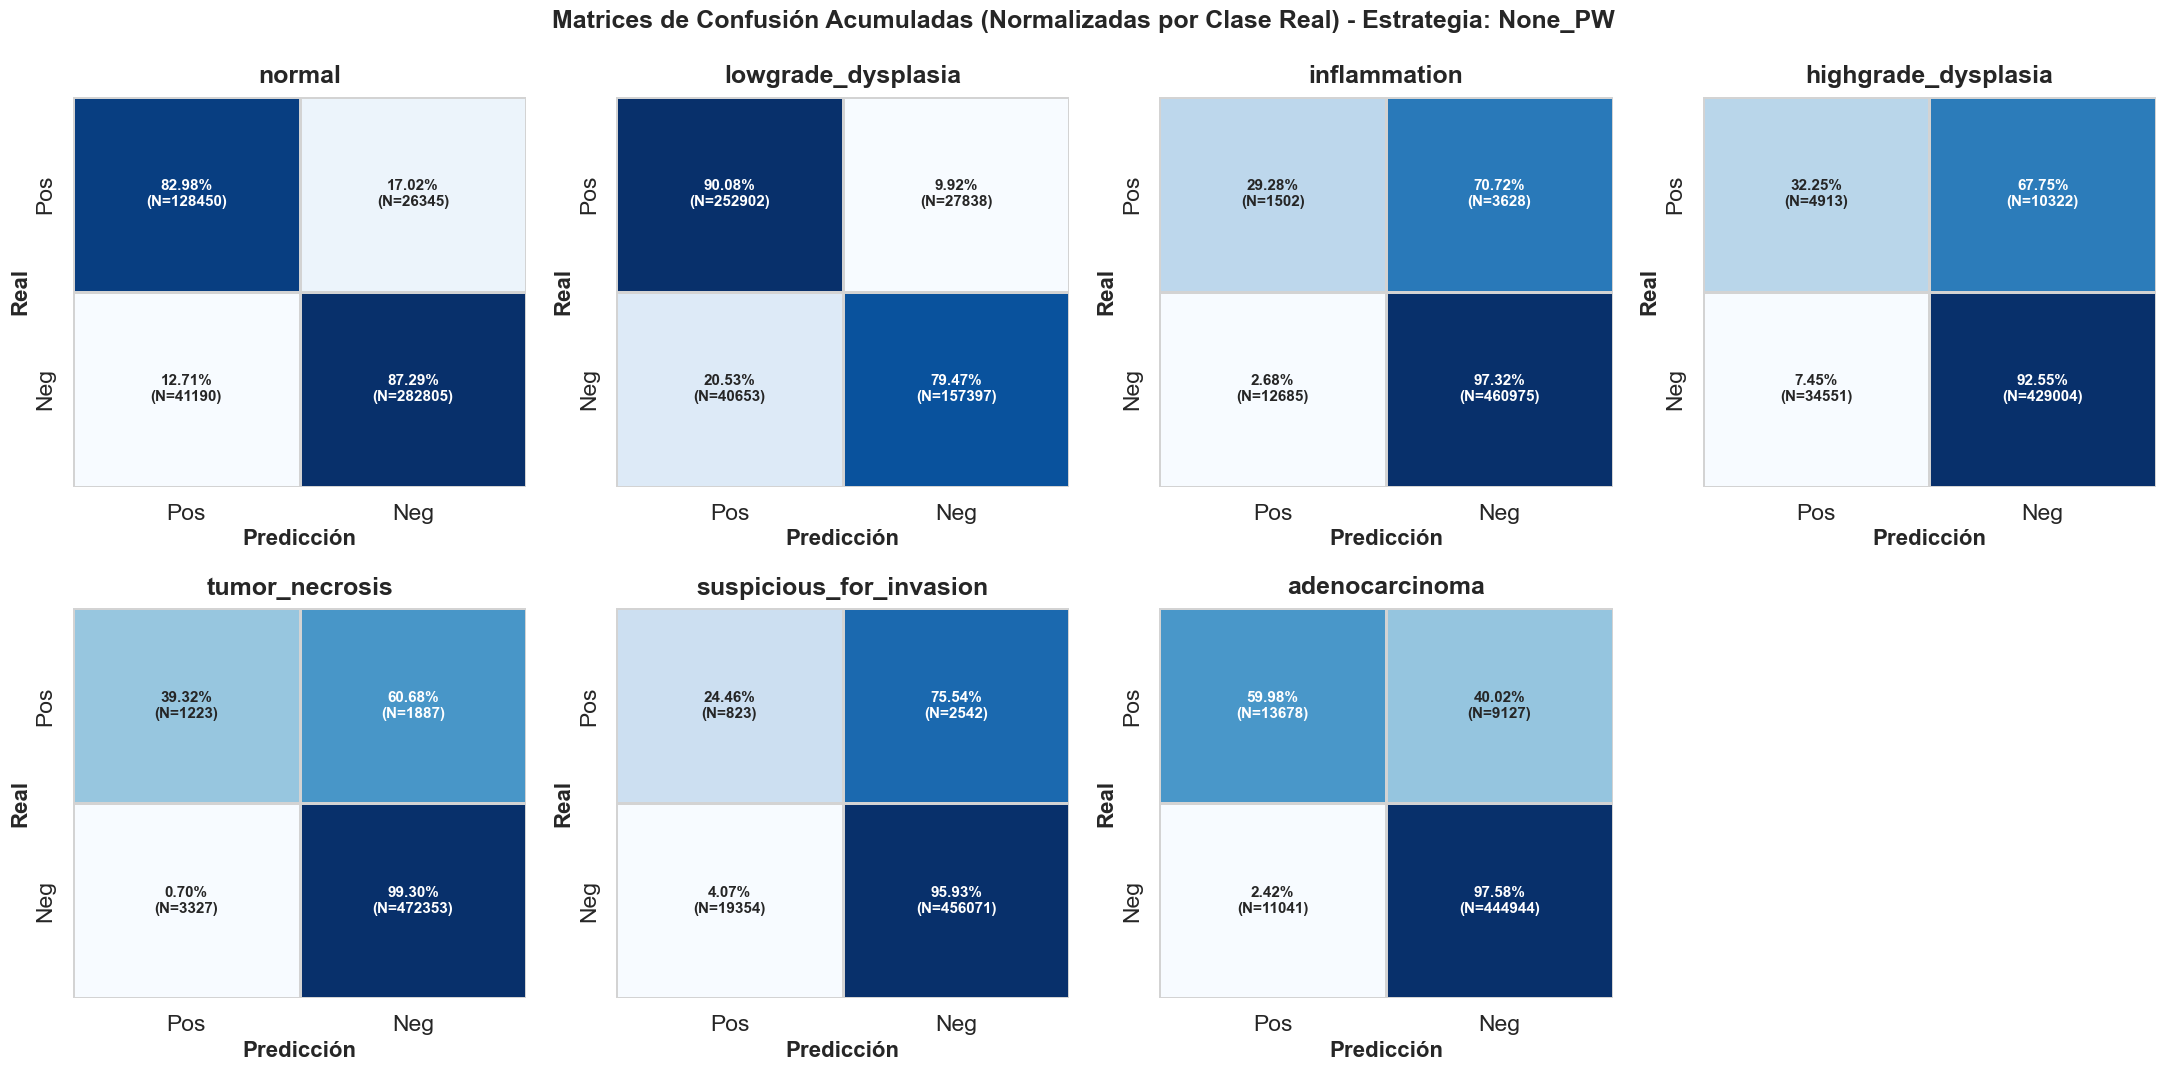

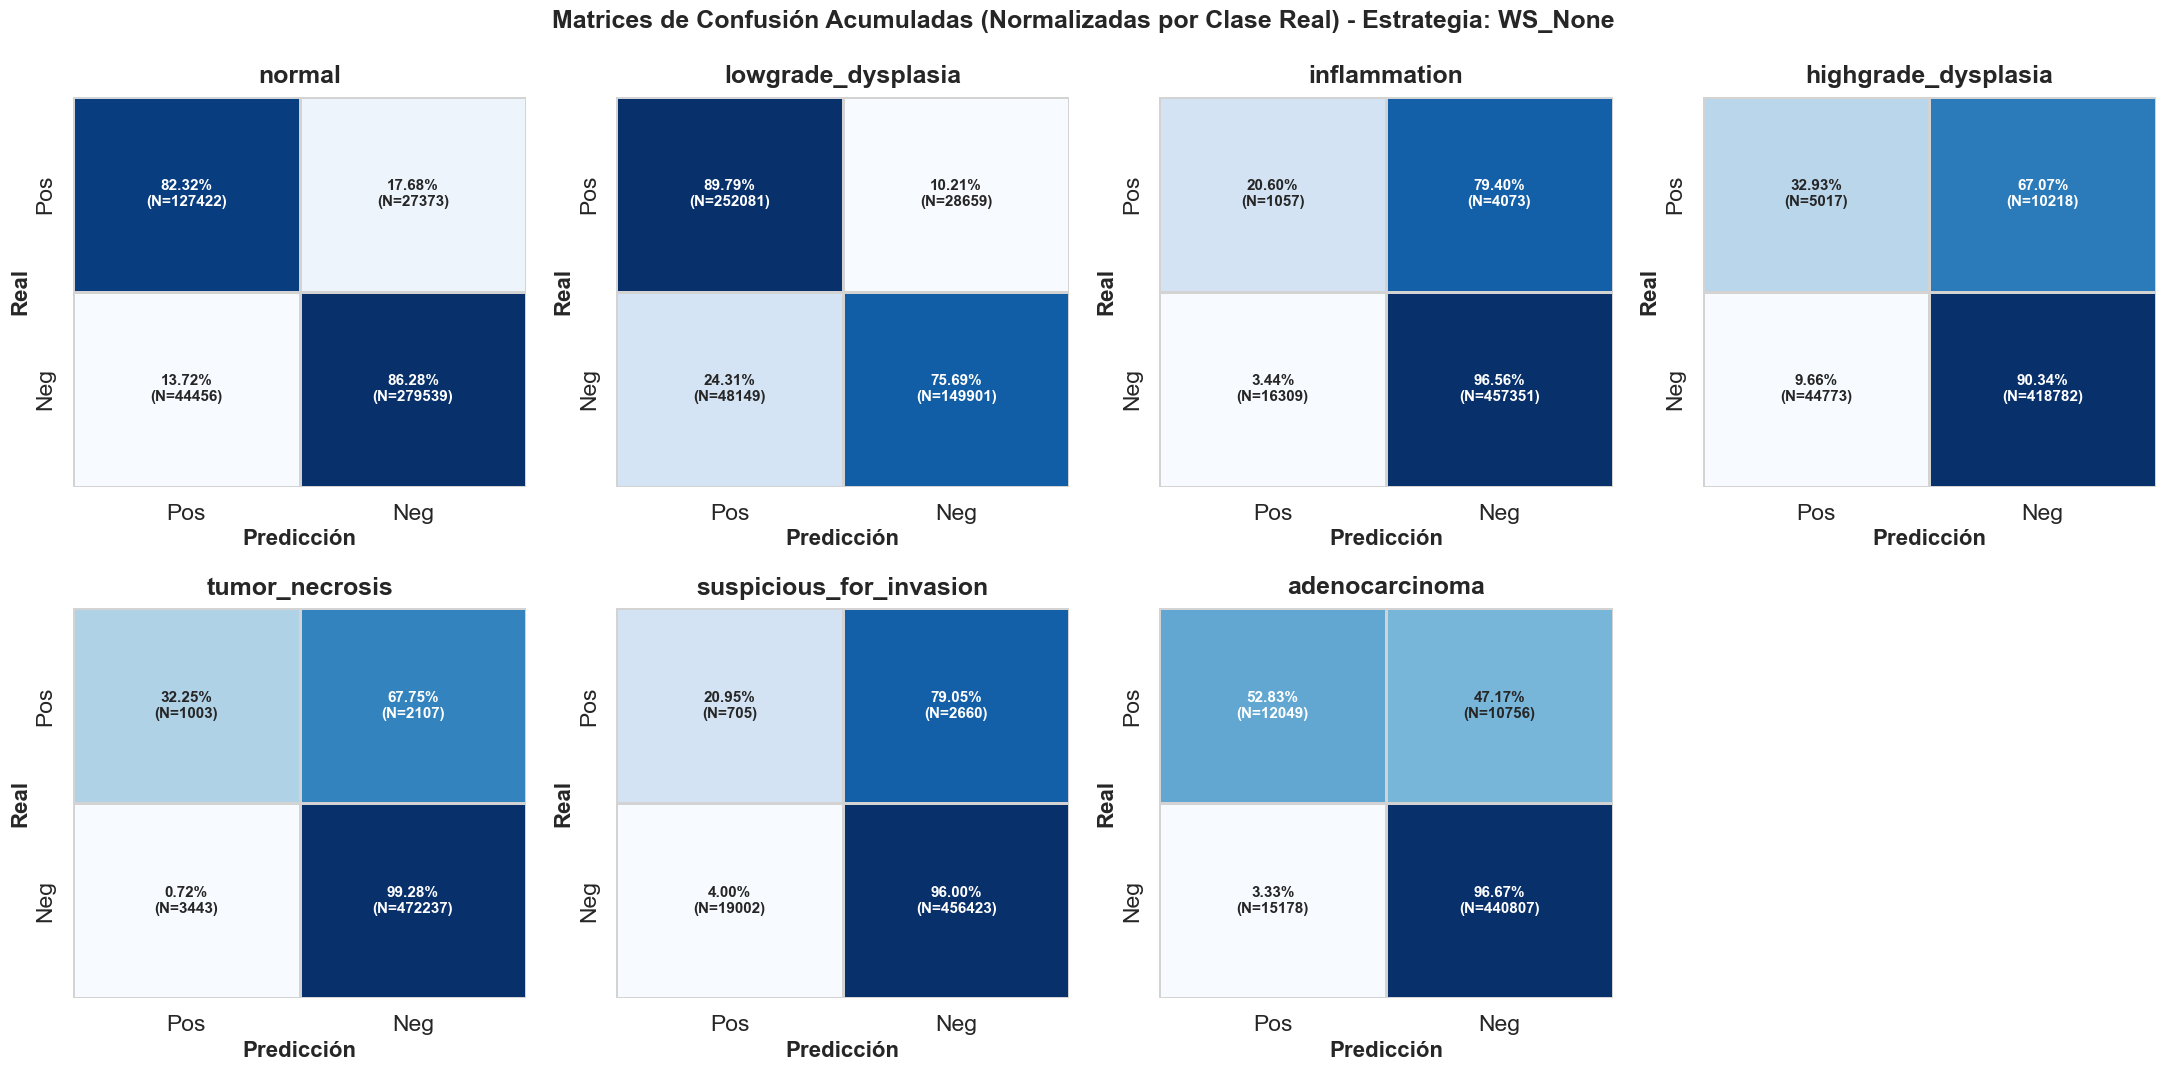

In [16]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path 

# --- CONFIGURACIÓN DE RUTAS Y EXPERIMENTOS ---
ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')
DATA_DIR = ROOT / 'Model_output'

SEEDS = [22, 32, 42, 52, 62]
FOLDS = [1, 2, 3, 4, 5]
ESTRATEGIAS = ["None_None", "None_ASL", "None_PW", "WS_None"]
CLASES = ["normal", "lowgrade_dysplasia", "inflammation", "highgrade_dysplasia", "tumor_necrosis", "suspicious_for_invasion", "adenocarcinoma"]

def cargar_predicciones_del_usuario(seed, fold, estrategia):
    """
    Carga las predicciones desde un archivo CSV para una combinación específica
    de semilla, fold y estrategia.
    
    Retorna un diccionario: 
    {
        "nombre_clase": (y_true_array, y_prob_array),
        ...
    }
    """
    # 1. Construimos el nombre del archivo CSV. Ajusta el prefijo si es necesario.
    nombre_archivo = f"predictions_seed_{seed}_fold{fold}_{estrategia}_test.csv"
    ruta_completa = os.path.join(DATA_DIR, nombre_archivo)
    
    # Control de seguridad si falta alguna partición
    if not os.path.exists(ruta_completa):
        print(f"⚠️ Archivo CSV no encontrado: {nombre_archivo}")
        return None
        
    # 2. Lectura del archivo CSV con pandas
    df = pd.read_csv(ruta_completa)
    
    resultado = {}
    
    # 3. Extraemos los datos para cada una de tus 7 clases
    for clase in CLASES:
        # =====================================================================
        # ADAPTACIÓN DE COLUMNAS: Cambia esto según los encabezados de tu CSV
        # =====================================================================
        # Ejemplo: Si para la clase 'normal' tus columnas se llaman 'normal_true' y 'normal_prob'
        col_true = f"{clase}_true"   # Nombre de la columna con los 0s y 1s reales
        col_prob = f"{clase}_prob"   # Nombre de la columna con las probabilidades continuas
        
        # Verificamos si ambas columnas existen en el CSV para esa clase
        if col_true in df.columns and col_prob in df.columns:
            resultado[clase] = (
                df[col_true].to_numpy(),
                df[col_prob].to_numpy()
            )
        else:
            # Si tus columnas tienen otro patrón, intenta buscar por aproximación o avisa del error
            print(f"⚠️ Columnas '{col_true}' o '{col_prob}' no encontradas en {nombre_archivo}")
            
    # Retorna el diccionario estructurado si logró mapear clases
    return resultado if resultado else None
    pass


# =====================================================================
# 2. EXTRACCIÓN DEL UMBRAL ÓPTIMO DESDE EL CHECKPOINT (.pth)
# =====================================================================
def obtener_threshold_desde_checkpoint(seed, fold, estrategia, clase):
    nombre_pth = f"best_model_seed_{seed}_fold_{fold}_strategy_{estrategia}.pth"
    ruta_pth = os.path.join(DATA_DIR, nombre_pth)
    
    if os.path.exists(ruta_pth):
        try:
            # Forzamos la carga en CPU
            checkpoint = torch.load(ruta_pth, map_location="cpu")
            
            # Buscamos la clave donde guardaste los thresholds. 
            # Si no se llama 'best_thresholds', cámbiala aquí:
            thresholds_data = checkpoint.get("thresholds", None)
            
            if thresholds_data is not None:
                # CASO A: Se guardó como Diccionario -> {'normal': 0.69, 'inflammation': 0.49, ...}
                if isinstance(thresholds_data, dict):
                    return thresholds_data.get(clase, 0.5)
                
                # CASO B: Se guardó como Lista/Array/Tensor -> [0.69, 0.65, 0.49, ...]
                # Buscamos el índice numérico que le corresponde en tu lista global CLASES
                else:
                    idx = CLASES.index(clase) # Devuelve 0 para 'normal', 1 para 'lowgrade_dysplasia', etc.
                    return float(thresholds_data[idx])
            else:
                print(f"⚠️ Clave 'best_thresholds' no encontrada en {nombre_pth}. Usando 0.5.")
                return 0.5
                
        except Exception as e:
            print(f"⚠️ Error leyendo threshold en {nombre_pth}: {e}. Usando 0.5 por defecto.")
            return 0.5
            
    return 0.5


# =====================================================================
# 3. BUCLE PRINCIPAL DE ACUMULACIÓN (TP, TN, FP, FN)
# =====================================================================

# Inicializamos la estructura de almacenamiento acumulativo
# acumulado[estrategia][clase] = {"TN": 0, "FP": 0, "FN": 0, "TP": 0}
acumulado = {est: {clase: {"TN": 0, "FP": 0, "FN": 0, "TP": 0} for clase in CLASES} for est in ESTRATEGIAS}

print("🚀 Iniciando la acumulación de predicciones...")

for seed in SEEDS:
    for fold in FOLDS:
        for est in ESTRATEGIAS:
            
            # Cargar las predicciones continuas del fold actual
            preds = cargar_predicciones_del_usuario(seed, fold, est)
            if preds is None:
                continue # Saltarse el modelo si no encuentra el archivo
                
            for clase in CLASES:
                if clase not in preds:
                    continue
                
                y_true, y_prob = preds[clase]
                
                # Obtener el umbral dinámico específico de este checkpoint
                thresh = obtener_threshold_desde_checkpoint(seed, fold, est, clase)
                
                # Binarizar las probabilidades usando el umbral extraído
                y_pred = (y_prob >= thresh).astype(int)
                
                # Calcular la matriz de confusión asegurando estructura 2x2 mediante 'labels'
                cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
                tn, fp, fn, tp = cm.ravel()
                
                # Acumular los totales
                acumulado[est][clase]["TN"] += tn
                acumulado[est][clase]["FP"] += fp
                acumulado[est][clase]["FN"] += fn
                acumulado[est][clase]["TP"] += tp

print("✅ Conteo acumulado finalizado con éxito.")


sns.set_theme(style="white", context="talk")

for est in ESTRATEGIAS:
    # Creamos una cuadrícula de 2x4 (dejando el hueco 8 libre para mantener tu diseño limpio)
    fig, axes = plt.subplots(2, 4, figsize=(22, 11))
    axes_flat = axes.flatten()
    
    for i, clase in enumerate(CLASES):
        ax = axes_flat[i]
        
        # Recuperamos los datos acumulados totales (suma de los 25 modelos)
        tn = acumulado[est][clase]["TN"]
        fp = acumulado[est][clase]["FP"]
        fn = acumulado[est][clase]["FN"]
        tp = acumulado[est][clase]["TP"]
        
        # --- NUEVA LÓGICA DE PORCENTAJES POR FILA (REALES) ---
        total_negativos_reales = tn + fp
        total_positivos_reales = fn + tp
        
        # Calculamos porcentajes independientes por fila controlando división por cero
        tn_pct = (tn / total_negativos_reales) * 100 if total_negativos_reales > 0 else 0.0
        fp_pct = (fp / total_negativos_reales) * 100 if total_negativos_reales > 0 else 0.0
        
        fn_pct = (fn / total_positivos_reales) * 100 if total_positivos_reales > 0 else 0.0
        tp_pct = (tp / total_positivos_reales) * 100 if total_positivos_reales > 0 else 0.0
        
        # Matriz de porcentajes para el código de colores del heatmap
        porcentajes = np.array([
            [tp_pct, fn_pct],
            [fp_pct, tn_pct]
        ])
        
        # Formatear el texto tal y como pediste: Porcentaje + \n + (N= conteo)
        labels_texto = np.array([
            [f"{tp_pct:.2f}%\n(N={tp})", f"{fn_pct:.2f}%\n(N={fn})"],
            [f"{fp_pct:.2f}%\n(N={fp})", f"{tn_pct:.2f}%\n(N={tn})"]
        ])
        
        # Dibujar heatmap
        sns.heatmap(
            porcentajes,         # El color ahora degrada según el porcentaje de su propia fila
            annot=labels_texto,  # Tu texto personalizado adaptado
            fmt="",              # Desactiva el formateador automático
            cmap="Blues",        # Paleta elegante de azules
            cbar=False,          # Quitamos la barra lateral para evitar ruido visual
            ax=ax,
            xticklabels=["Pos", "Neg"],
            yticklabels=["Pos", "Neg"],
            annot_kws={"size": 11, "weight": "bold"},
            linewidths=1,
            linecolor="lightgray"
        )
        
        ax.set_xlabel("Predicción", weight='bold', size=16, labelpad=4)
        ax.set_ylabel("Real", weight='bold', size=16, labelpad=4)
        
        ax.set_title(f"{clase}", weight='bold', size=18, pad=10)
        
    # Ocultar por completo el cuadrante 8 sobrante para mantener simetría estética
    axes_flat[7].axis('off')
    
    # Ajustes de títulos generales
    plt.suptitle(f"Matrices de Confusión Acumuladas (Normalizadas por Clase Real) - Estrategia: {est}", weight='bold', size=18, y=0.98)
    plt.tight_layout()
    
    # Guardar gráfica de forma independiente
    plt.savefig(ROOT / 'plots_interesantes' / f"confusion_matrix_acumulada_{est}.png", dpi=300, bbox_inches='tight')
    plt.show()

🚀 Iniciando la acumulación de predicciones...
✅ Conteo acumulado finalizado con éxito.


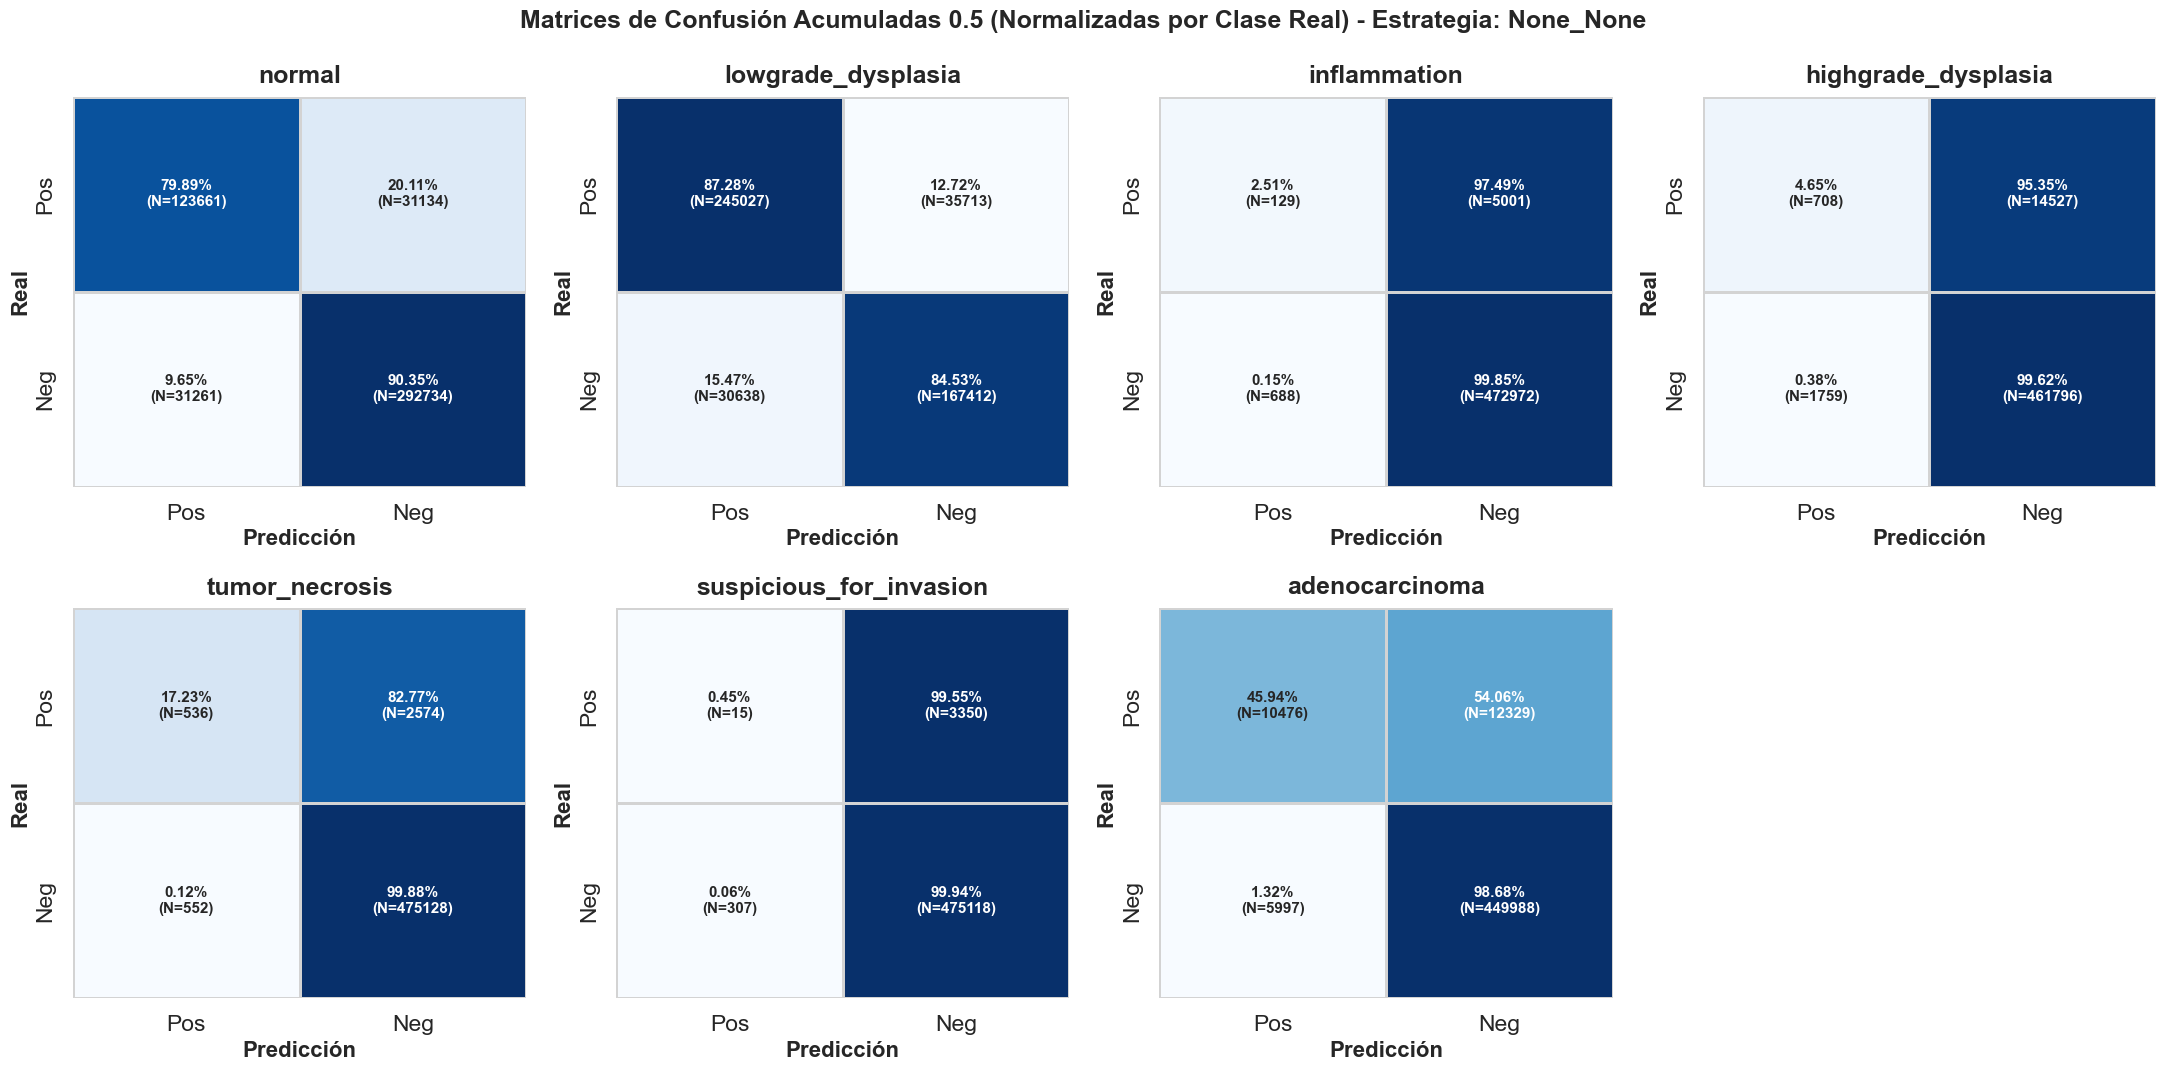

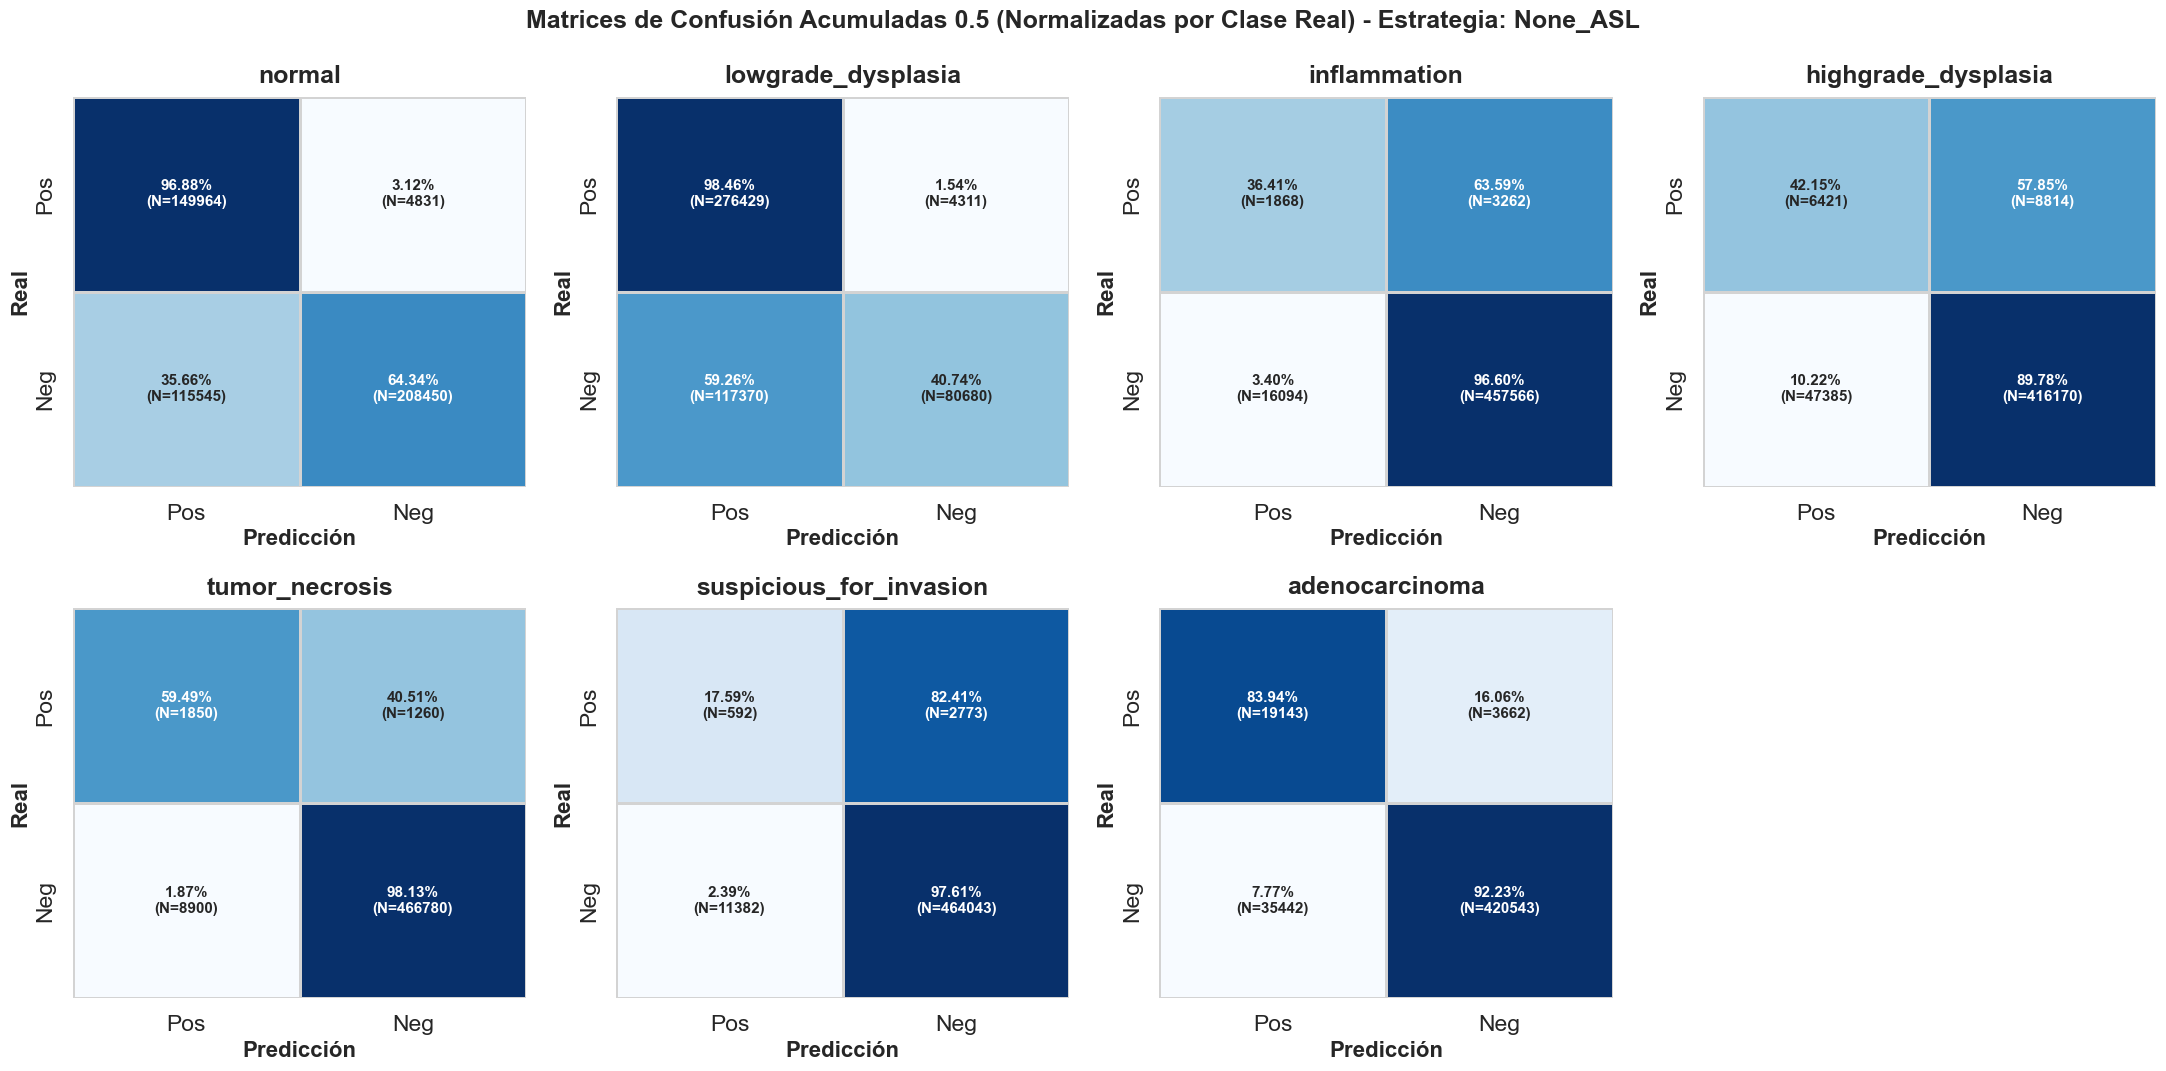

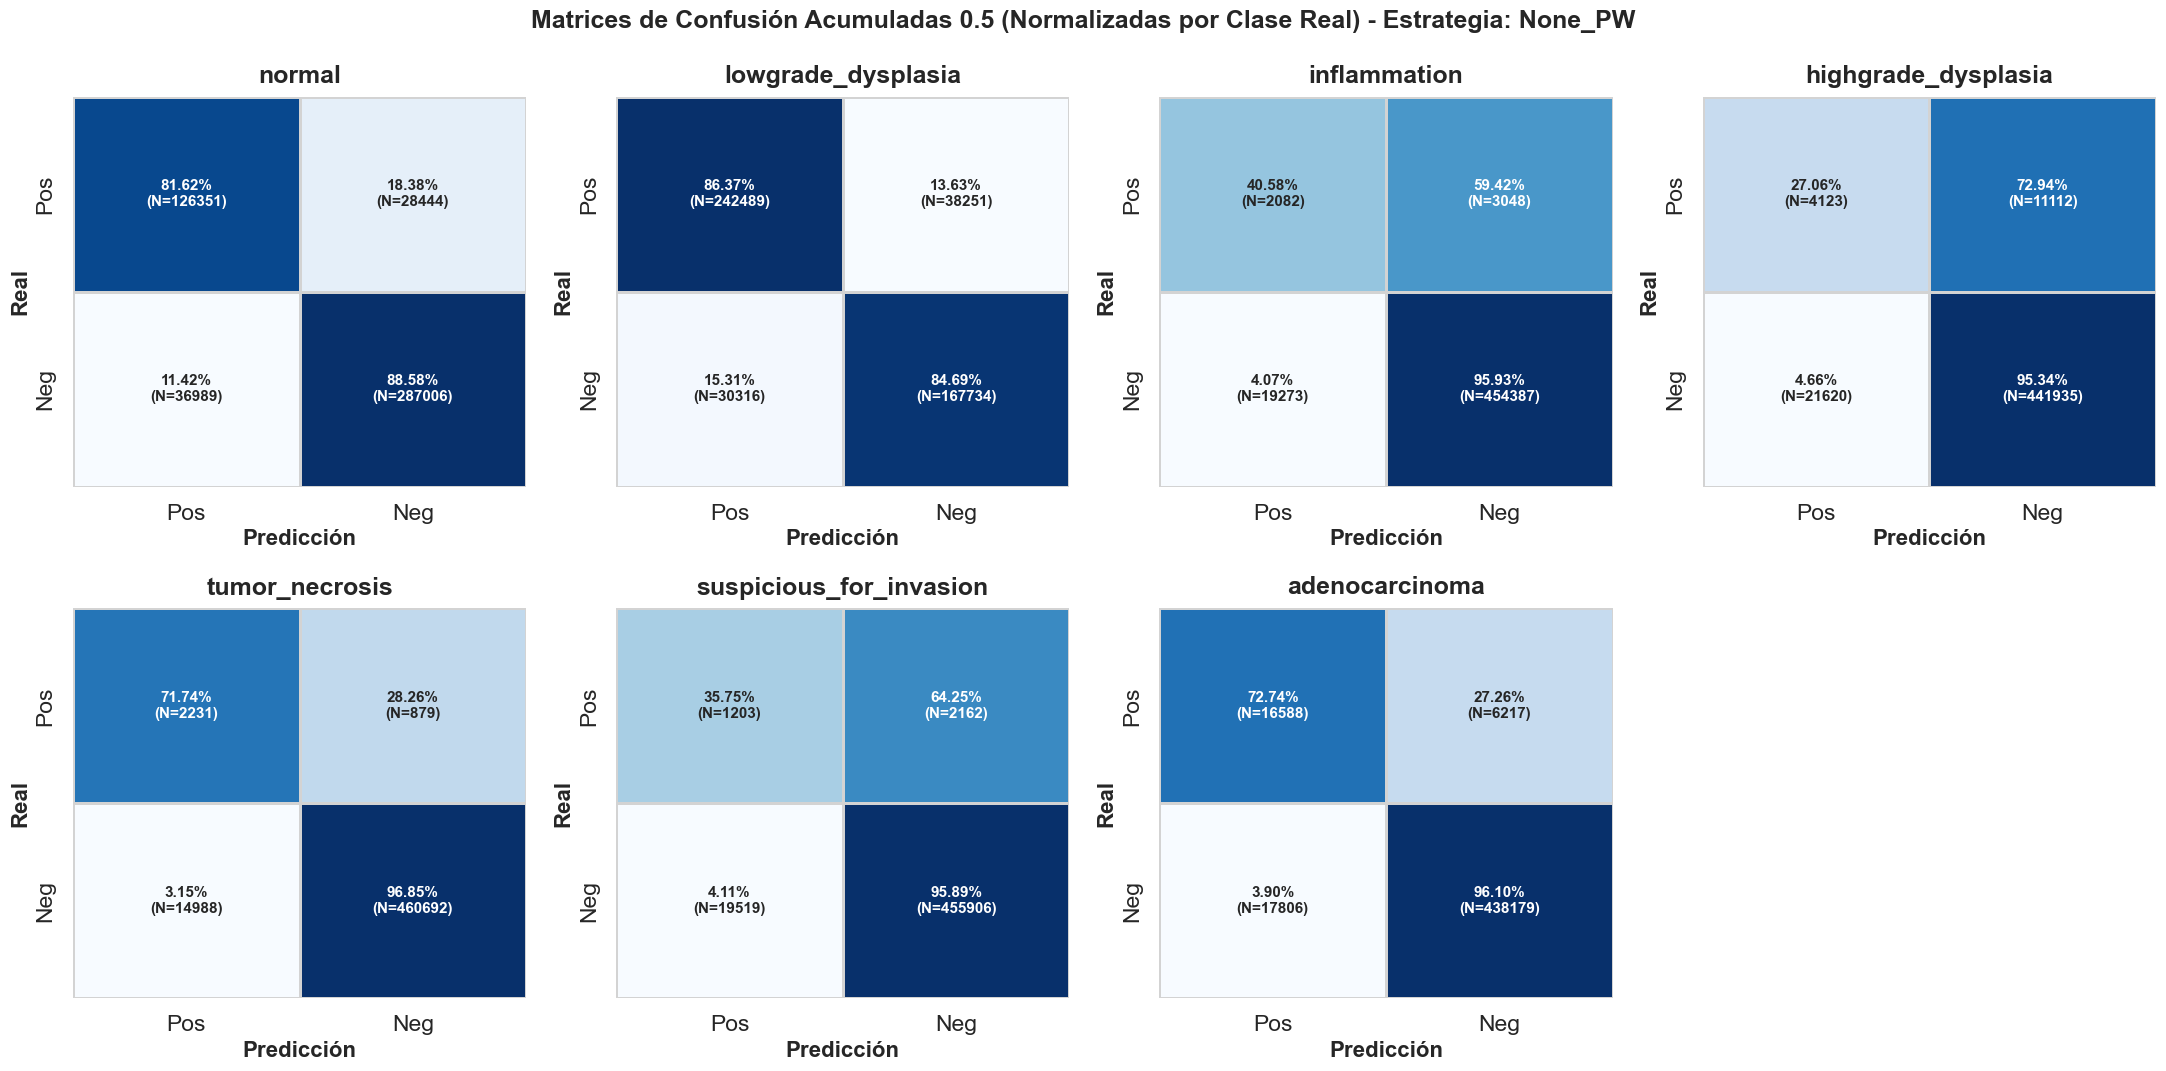

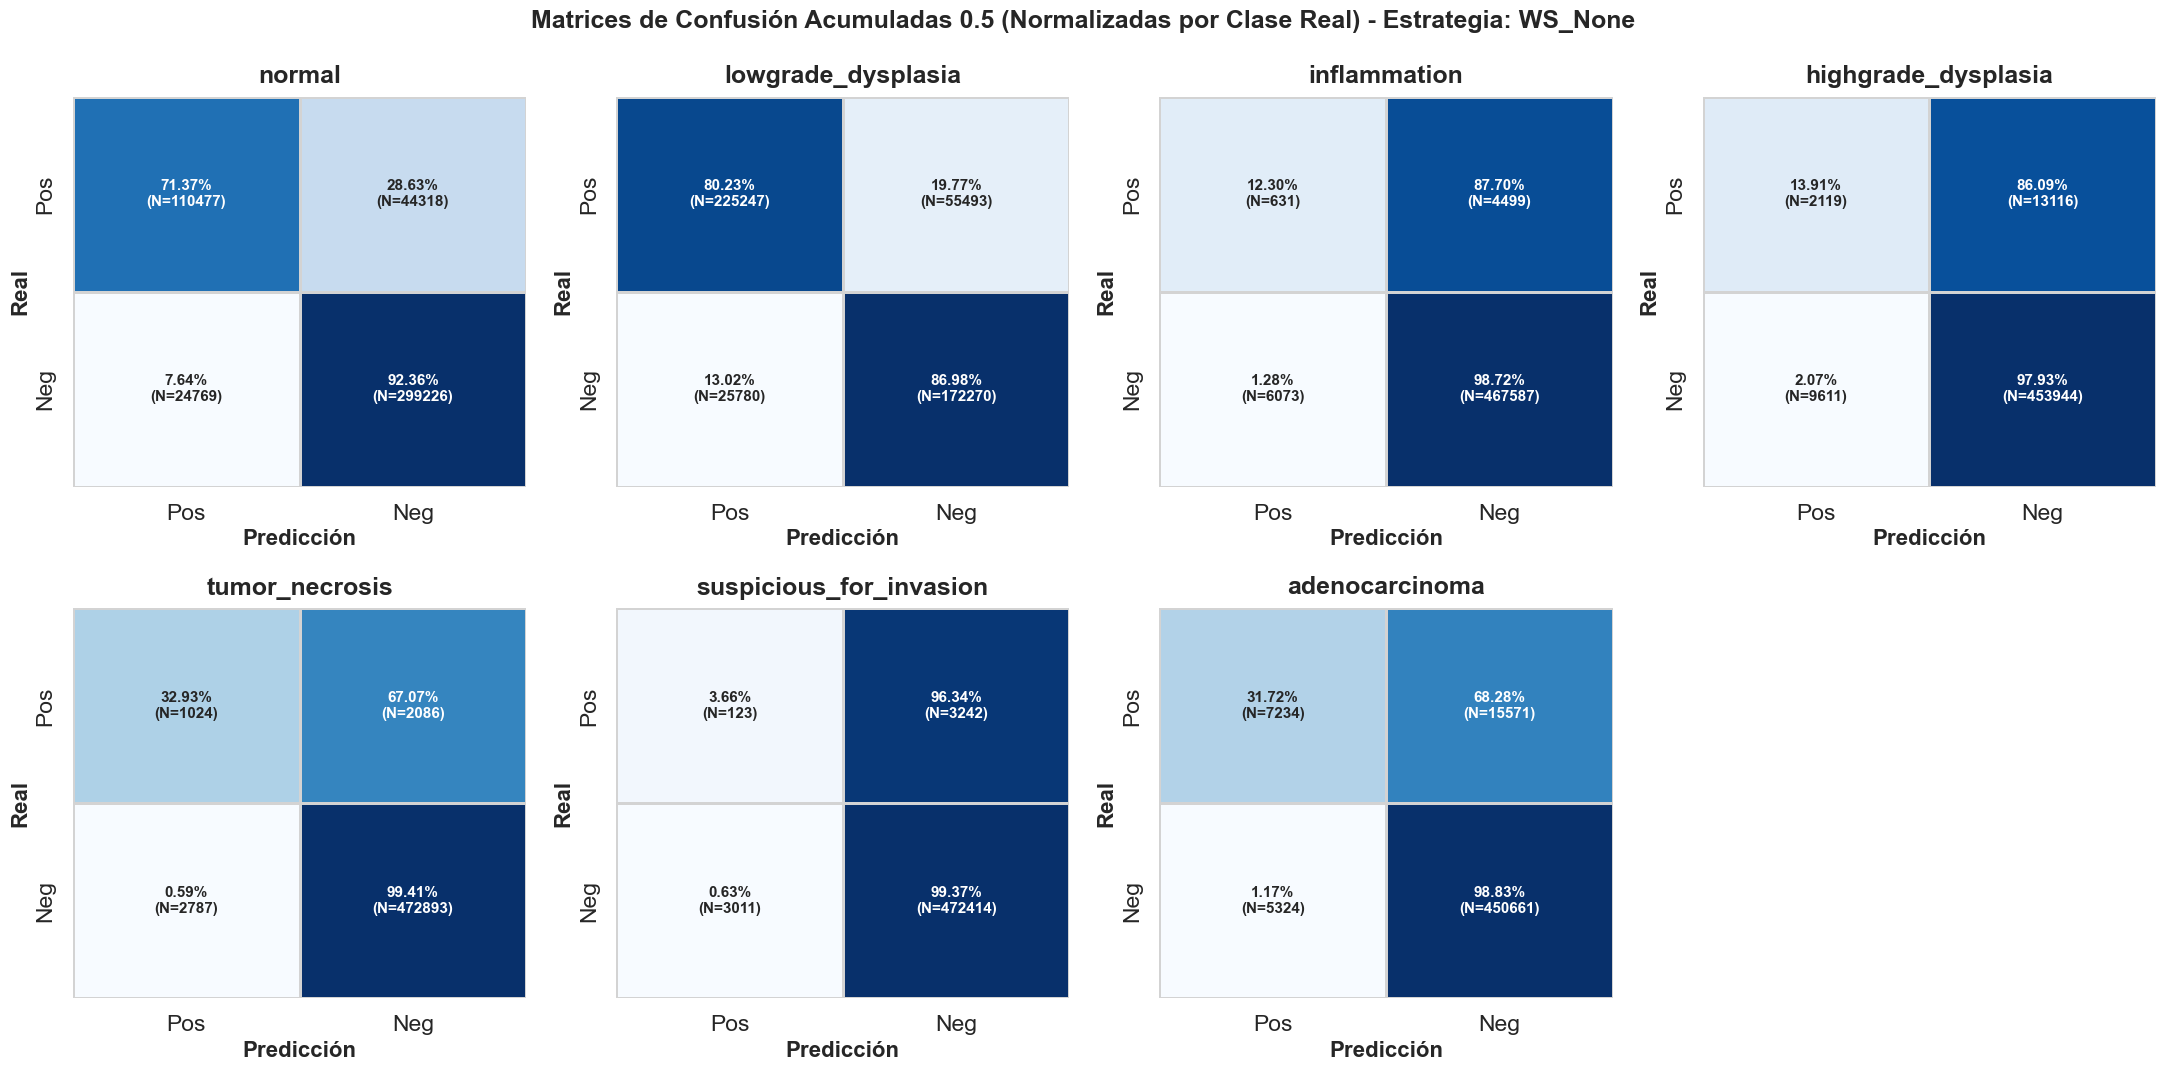

In [15]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path 

# --- CONFIGURACIÓN DE RUTAS Y EXPERIMENTOS ---
ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')
DATA_DIR = ROOT / 'Model_output'

SEEDS = [22, 32, 42, 52, 62]
FOLDS = [1, 2, 3, 4, 5]
ESTRATEGIAS = ["None_None", "None_ASL", "None_PW", "WS_None"]
CLASES = ["normal", "lowgrade_dysplasia", "inflammation", "highgrade_dysplasia", "tumor_necrosis", "suspicious_for_invasion", "adenocarcinoma"]

def cargar_predicciones_del_usuario(seed, fold, estrategia):
    """
    Carga las predicciones desde un archivo CSV para una combinación específica
    de semilla, fold y estrategia.
    
    Retorna un diccionario: 
    {
        "nombre_clase": (y_true_array, y_prob_array),
        ...
    }
    """
    # 1. Construimos el nombre del archivo CSV. Ajusta el prefijo si es necesario.
    nombre_archivo = f"predictions_seed_{seed}_fold{fold}_{estrategia}_test.csv"
    ruta_completa = os.path.join(DATA_DIR, nombre_archivo)
    
    # Control de seguridad si falta alguna partición
    if not os.path.exists(ruta_completa):
        print(f"⚠️ Archivo CSV no encontrado: {nombre_archivo}")
        return None
        
    # 2. Lectura del archivo CSV con pandas
    df = pd.read_csv(ruta_completa)
    
    resultado = {}
    
    # 3. Extraemos los datos para cada una de tus 7 clases
    for clase in CLASES:
        # =====================================================================
        # ADAPTACIÓN DE COLUMNAS: Cambia esto según los encabezados de tu CSV
        # =====================================================================
        # Ejemplo: Si para la clase 'normal' tus columnas se llaman 'normal_true' y 'normal_prob'
        col_true = f"{clase}_true"   # Nombre de la columna con los 0s y 1s reales
        col_prob = f"{clase}_prob"   # Nombre de la columna con las probabilidades continuas
        
        # Verificamos si ambas columnas existen en el CSV para esa clase
        if col_true in df.columns and col_prob in df.columns:
            resultado[clase] = (
                df[col_true].to_numpy(),
                df[col_prob].to_numpy()
            )
        else:
            # Si tus columnas tienen otro patrón, intenta buscar por aproximación o avisa del error
            print(f"⚠️ Columnas '{col_true}' o '{col_prob}' no encontradas en {nombre_archivo}")
            
    # Retorna el diccionario estructurado si logró mapear clases
    return resultado if resultado else None
    pass



# =====================================================================
# 3. BUCLE PRINCIPAL DE ACUMULACIÓN (TP, TN, FP, FN)
# =====================================================================

# Inicializamos la estructura de almacenamiento acumulativo
# acumulado[estrategia][clase] = {"TN": 0, "FP": 0, "FN": 0, "TP": 0}
acumulado = {est: {clase: {"TN": 0, "FP": 0, "FN": 0, "TP": 0} for clase in CLASES} for est in ESTRATEGIAS}

print("🚀 Iniciando la acumulación de predicciones...")

for seed in SEEDS:
    for fold in FOLDS:
        for est in ESTRATEGIAS:
            
            # Cargar las predicciones continuas del fold actual
            preds = cargar_predicciones_del_usuario(seed, fold, est)
            if preds is None:
                continue # Saltarse el modelo si no encuentra el archivo
                
            for clase in CLASES:
                if clase not in preds:
                    continue
                
                y_true, y_prob = preds[clase]
                
                # Binarizar las probabilidades usando el umbral extraído
                y_pred = (y_prob >= 0.5).astype(int)
                
                # Calcular la matriz de confusión asegurando estructura 2x2 mediante 'labels'
                cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
                tn, fp, fn, tp = cm.ravel()
                
                # Acumular los totales
                acumulado[est][clase]["TN"] += tn
                acumulado[est][clase]["FP"] += fp
                acumulado[est][clase]["FN"] += fn
                acumulado[est][clase]["TP"] += tp

print("✅ Conteo acumulado finalizado con éxito.")


sns.set_theme(style="white", context="talk")

for est in ESTRATEGIAS:
    # Creamos una cuadrícula de 2x4 (dejando el hueco 8 libre para mantener tu diseño limpio)
    fig, axes = plt.subplots(2, 4, figsize=(22, 11))
    axes_flat = axes.flatten()
    
    for i, clase in enumerate(CLASES):
        ax = axes_flat[i]
        
        # Recuperamos los datos acumulados totales (suma de los 25 modelos)
        tn = acumulado[est][clase]["TN"]
        fp = acumulado[est][clase]["FP"]
        fn = acumulado[est][clase]["FN"]
        tp = acumulado[est][clase]["TP"]
        
        # --- NUEVA LÓGICA DE PORCENTAJES POR FILA (REALES) ---
        total_negativos_reales = tn + fp
        total_positivos_reales = fn + tp
        
        # Calculamos porcentajes independientes por fila controlando división por cero
        tn_pct = (tn / total_negativos_reales) * 100 if total_negativos_reales > 0 else 0.0
        fp_pct = (fp / total_negativos_reales) * 100 if total_negativos_reales > 0 else 0.0
        
        fn_pct = (fn / total_positivos_reales) * 100 if total_positivos_reales > 0 else 0.0
        tp_pct = (tp / total_positivos_reales) * 100 if total_positivos_reales > 0 else 0.0
        
        # Matriz de porcentajes para el código de colores del heatmap
        porcentajes = np.array([
            [tp_pct, fn_pct],
            [fp_pct, tn_pct]
        ])
        
        # Formatear el texto tal y como pediste: Porcentaje + \n + (N= conteo)
        labels_texto = np.array([
            [f"{tp_pct:.2f}%\n(N={tp})", f"{fn_pct:.2f}%\n(N={fn})"],
            [f"{fp_pct:.2f}%\n(N={fp})", f"{tn_pct:.2f}%\n(N={tn})"]
        ])
        
        # Dibujar heatmap
        sns.heatmap(
            porcentajes,         # El color ahora degrada según el porcentaje de su propia fila
            annot=labels_texto,  # Tu texto personalizado adaptado
            fmt="",              # Desactiva el formateador automático
            cmap="Blues",        # Paleta elegante de azules
            cbar=False,          # Quitamos la barra lateral para evitar ruido visual
            ax=ax,
            xticklabels=["Pos", "Neg"],
            yticklabels=["Pos", "Neg"],
            annot_kws={"size": 11, "weight": "bold"},
            linewidths=1,
            linecolor="lightgray"
        )
        
        ax.set_xlabel("Predicción", weight='bold', size=16, labelpad=4)
        ax.set_ylabel("Real", weight='bold', size=16, labelpad=4)
        
        ax.set_title(f"{clase}", weight='bold', size=18, pad=10)
        
    # Ocultar por completo el cuadrante 8 sobrante para mantener simetría estética
    axes_flat[7].axis('off')
    
    # Ajustes de títulos generales
    plt.suptitle(f"Matrices de Confusión Acumuladas 0.5 (Normalizadas por Clase Real) - Estrategia: {est}", weight='bold', size=18, y=0.98)
    plt.tight_layout()
    
    # Guardar gráfica de forma independiente
    plt.savefig(ROOT / 'plots_interesantes' / f"confusion_matrix_acumulada_0.5_{est}.png", dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path 

# --- CONFIGURACIÓN DE RUTAS Y EXPERIMENTOS ---
ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')
DATA_DIR = ROOT / 'Model_output_hierarchical'

SEEDS = [22, 32, 42, 52, 62]
FOLDS = [1, 2, 3, 4, 5]
CLASES = ["normal", "inflammation", "lowgrade_dysplasia",  "highgrade_dysplasia", "tumor_necrosis", "suspicious_for_invasion", "adenocarcinoma"]

acumulado_mc = np.zeros((len(CLASES), len(CLASES)), dtype=np.int64)

for seed in SEEDS:
    for fold in FOLDS:
        nombre_archivo = (
            f"predictions_hierarchical_seed_{seed}_fold_{fold}_test.csv"
        )

        ruta = DATA_DIR / nombre_archivo

        if not ruta.exists():
            print(f"⚠️ No encontrado: {nombre_archivo}")
            continue

        df = pd.read_csv(ruta)

        y_true = df["true_label"].values
        y_pred = df["pred_label"].values

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=np.arange(len(CLASES))
        )

        acumulado_mc += cm
            
            
cm = acumulado_mc

cm_pct = (
    cm.astype(float)
    / cm.sum(axis=1, keepdims=True)
) * 100

annot = np.empty_like(cm, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        annot[i, j] = (
            f"{cm_pct[i,j]:.1f}%\n"
            f"(N={cm[i,j]})"
        )

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_pct,
    annot=annot,
    fmt="",
    cmap="Blues",
    xticklabels=CLASES,
    yticklabels=CLASES,
    linewidths=0.5
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")

plt.title(
    "Matriz de confusión acumulada\n",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    ROOT / "plots_interesantes" /
    "confusion_matrix_multiclase.png",
    dpi=300
)

plt.show()

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path 

# --- CONFIGURACIÓN DE RUTAS Y EXPERIMENTOS ---
ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto')
DATA_DIR = ROOT / 'UNI_output_hierarchical'

SEEDS = [22, 32, 42, 52, 62]
FOLDS = [1, 2, 3, 4, 5]
CLASES = ["normal", "inflammation", "lowgrade_dysplasia",  "highgrade_dysplasia", "tumor_necrosis", "suspicious_for_invasion", "adenocarcinoma"]

acumulado_mc = np.zeros((len(CLASES), len(CLASES)), dtype=np.int64)

for seed in SEEDS:
    for fold in FOLDS:
        nombre_archivo = (
            f"predictions_hierarchical_seed_{seed}_fold_{fold}_test.csv"
        )

        ruta = DATA_DIR / nombre_archivo

        if not ruta.exists():
            print(f"⚠️ No encontrado: {nombre_archivo}")
            continue

        df = pd.read_csv(ruta)

        y_true = df["true_label"].values
        y_pred = df["pred_label"].values

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=np.arange(len(CLASES))
        )

        acumulado_mc += cm
            
            
cm = acumulado_mc

cm_pct = (
    cm.astype(float)
    / cm.sum(axis=1, keepdims=True)
) * 100

annot = np.empty_like(cm, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        annot[i, j] = (
            f"{cm_pct[i,j]:.1f}%\n"
            f"(N={cm[i,j]})"
        )

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_pct,
    annot=annot,
    fmt="",
    cmap="Blues",
    xticklabels=CLASES,
    yticklabels=CLASES,
    linewidths=0.5
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")

plt.title(
    "Matriz de confusión acumulada\n",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    ROOT / "plots_interesantes" /
    "UNI_confusion_matrix_multiclase.png",
    dpi=300
)

plt.show()